# MPA-MLF — Radar Image Classification (CNN)

> **Goal**: Classify radar heatmaps into 4 classes (0–3 persons detected)  
> **Dataset**: 9770 training images (45×51 px), 4 classes with strong imbalance  
> **Best result**: Multi-architecture ensemble (Deeper LS 0.05 + Wider LS 0.05) — **0.97819 Kaggle public**

---

## Table of Contents

1. **SETUP** — Imports & Configuration
2. **EDA** — Exploratory Data Analysis
3. **PIPELINE** — Data loading & preprocessing
4. **MODELS** — Architecture definitions
5. **TRAINING** — Baseline CNN & Hyperparameter tuning
6. **EXPERIMENTS** — Augmentation, Regularisation, Transfer Learning
7. **ENSEMBLE & ADVANCED TECHNIQUES** — Ensemble strategies, advanced losses, architecture search

---


In [2]:
# ── Colab setup (skipped automatically when running locally) ──────────────
import sys
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # Verify GPU
    import tensorflow as tf
    gpus = tf.config.list_physical_devices("GPU")
    if not gpus:
        print("⚠️  No GPU detected — go to Runtime → Change runtime type → T4 GPU")
    else:
        print(f"✅ GPU ready: {gpus[0].name}")
    # Install any missing packages
    # (TF, numpy, pandas, sklearn, PIL, matplotlib are pre-installed on Colab)
    print("✅ Colab environment ready")
else:
    print("Running locally.")
# ─────────────────────────────────────────────────────────────────────────


Running locally.


# 1 — SETUP

## Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import PIL.Image as Image
import os

## Configuration

In [31]:
import sys, os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE = "/content/drive/MyDrive/MPA-MLF"
else:
    BASE = "."  # local — relative paths

TRAIN_DIR = os.path.join(BASE, "input_dataset", "x_train")
TEST_DIR  = os.path.join(BASE, "input_dataset", "x_test")
Y_TRAIN   = os.path.join(BASE, "input_dataset", "y_train.csv")
Y_TEST    = os.path.join(BASE, "input_dataset", "y_test_submission_example.csv")
SUB_DIR   = os.path.join(BASE, "submissions")
os.makedirs(SUB_DIR, exist_ok=True)


# 2 — EDA

## 2.1 — Load labels

In [5]:
df = pd.read_csv(Y_TRAIN)
print(f"Shape : {df.shape}")
df.head()

Shape : (9227, 2)


,id,target
0,0,0
1,1,1
2,2,0
3,3,2
4,4,2


## 2.2 — Class distribution

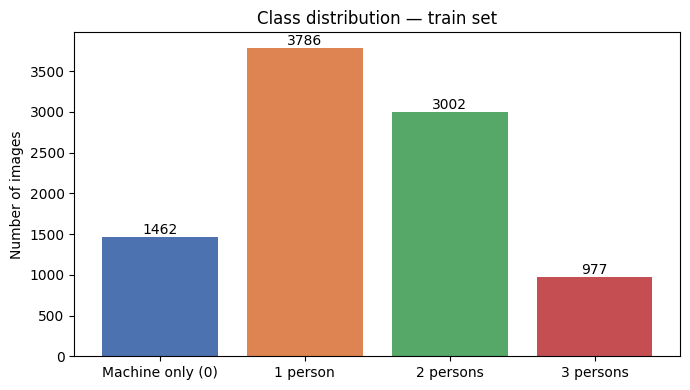

target
0    1462
1    3786
2    3002
3     977
Name: count, dtype: int64

Total: 9227 images


In [6]:
class_names = {0: "Machine only (0)", 1: "1 person", 2: "2 persons", 3: "3 persons"}
counts = df["target"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([class_names[i] for i in counts.index], counts.values, color=["#4C72B0","#DD8452","#55A868","#C44E52"])
ax.bar_label(bars, fmt="%d")
ax.set_title("Class distribution — train set")
ax.set_ylabel("Number of images")
plt.tight_layout()
plt.show()

print(counts)
print(f"\nTotal: {counts.sum()} images")

## 2.3 — Visual examples per class

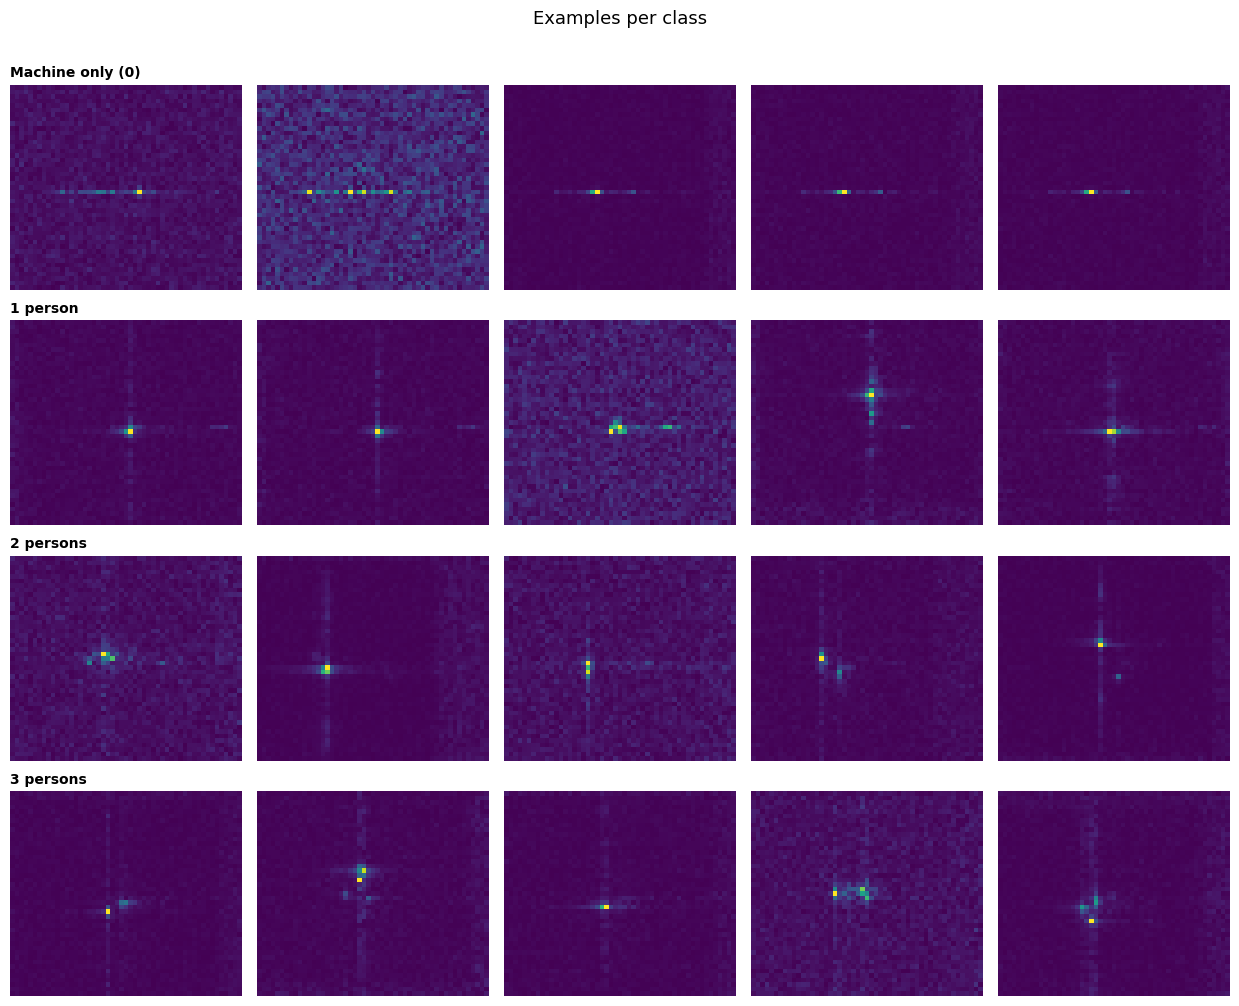

In [7]:
N_EXAMPLES = 5  # examples per class

fig, axes = plt.subplots(4, N_EXAMPLES, figsize=(N_EXAMPLES * 2.5, 10))

for cls in range(4):
    # Filter to IDs with existing images, then sample
    cls_ids = df[df["target"] == cls]["id"].values
    valid_ids = [i for i in cls_ids if os.path.exists(os.path.join(TRAIN_DIR, f"img_{i + 1}.png"))]
    samples = pd.Series(valid_ids).sample(N_EXAMPLES, random_state=42).values
    for col, img_id in enumerate(samples):
        img = Image.open(os.path.join(TRAIN_DIR, f"img_{img_id + 1}.png"))
        axes[cls, col].imshow(img)
        axes[cls, col].axis("off")
        if col == 0:
            axes[cls, col].set_title(class_names[cls], loc="left", fontsize=10, fontweight="bold")

plt.suptitle("Examples per class", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 2.4 — Image dimensions & pixel statistics

In [8]:
# Check dimensions on a sample of 100 images
# Filter to IDs with existing images before sampling
valid_ids = [i for i in df["id"].values if os.path.exists(os.path.join(TRAIN_DIR, f"img_{i + 1}.png"))]
sample_ids = pd.Series(valid_ids).sample(100, random_state=42).values
sizes = set()
pixel_values = []

for img_id in sample_ids:
    img = Image.open(os.path.join(TRAIN_DIR, f"img_{img_id + 1}.png"))
    sizes.add(img.size)
    pixel_values.append(np.array(img).flatten())

pixel_values = np.concatenate(pixel_values)

print(f"Valid images : {len(valid_ids)} / {len(df)}")
print(f"Unique image sizes : {sizes}")
print(f"Pixel min  : {pixel_values.min()}")
print(f"Pixel max  : {pixel_values.max()}")
print(f"Pixel mean : {pixel_values.mean():.2f}")
print(f"Pixel std  : {pixel_values.std():.2f}")


Valid images : 7163 / 9227
Unique image sizes : {(51, 45)}
Pixel min  : 1
Pixel max  : 253
Pixel mean : 58.09
Pixel std  : 36.08


# 3 — PIPELINE

Data loading, train/val split, and preprocessing.

In [75]:
from sklearn.model_selection import train_test_split

def load_dataset(img_dir, df):
    """Load all images into RAM. Returns (X, y) as numpy arrays.
    
    Convention: filename = img_{id+1}.png (CSV ids are 0-indexed,
    filenames are 1-indexed). Rows without a matching image are skipped.
    """
    X, y = [], []
    for _, row in df.iterrows():
        img_path = os.path.join(img_dir, f"img_{int(row['id']) + 1}.png")
        if not os.path.exists(img_path):
            continue  # skip labels without matching image
        img = Image.open(img_path).convert("RGB")
        X.append(np.array(img) / 255.0)
        y.append(int(row["target"]))
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)


print("Loading dataset...")
X, y = load_dataset(TRAIN_DIR, df)
print(f"X shape : {X.shape}  — dtype : {X.dtype}")
print(f"y shape : {y.shape}  — unique labels : {np.unique(y)}")
print(f"RAM usage (X) : ~{X.nbytes / 1e6:.1f} MB")

Loading dataset...
X shape : (7163, 45, 51, 3)  — dtype : float32
y shape : (7163,)  — unique labels : [0 1 2 3]
RAM usage (X) : ~197.3 MB


## 3.1 — Train / Validation split

In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # preserve class distribution in both splits
)

print(f"Train : {X_train.shape[0]} samples")
print(f"Val   : {X_val.shape[0]} samples")
print(f"\nClass distribution in train : {np.bincount(y_train)}")
print(f"Class distribution in val   : {np.bincount(y_val)}")

Train : 5730 samples
Val   : 1433 samples

Class distribution in train : [ 913 2345 1873  599]
Class distribution in val   : [228 586 469 150]


## 3.3 — Class weights

In [11]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

print("Class weights:")
for cls, w in class_weights.items():
    print(f"  Class {cls} ({class_names[cls]}) : {w:.3f}")

Class weights:
  Class 0 (Machine only (0)) : 1.569
  Class 1 (1 person) : 0.611
  Class 2 (2 persons) : 0.765
  Class 3 (3 persons) : 2.391


# 4 — MODELS

CNN architecture definitions.

In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def build_baseline_cnn(input_shape=(45, 51, 3), num_classes=4):
    model = keras.Sequential([
        # Input
        keras.Input(shape=input_shape),

        # Block 1
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        # Block 2
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        # Block 3
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        # Classifier
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ], name="baseline_cnn")
    return model

model = build_baseline_cnn()
model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 45, 51, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 22, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 22, 25, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3840)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       491,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 585,412 (2.23 MB)

 Trainable params: 585,412 (2.23 MB)

 Non-trainable params: 0 (0.00 B)

# 5 — TRAINING

## 5.1 — Baseline CNN

In [ ]:
model = build_baseline_cnn()
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True,
    verbose=1,
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1,
)

Epoch 1/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6375 - loss: 0.8281 - val_accuracy: 0.7837 - val_loss: 0.4972
Epoch 2/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8272 - loss: 0.4264 - val_accuracy: 0.8479 - val_loss: 0.3920
Epoch 3/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8490 - loss: 0.3701 - val_accuracy: 0.8716 - val_loss: 0.3096
Epoch 4/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8928 - loss: 0.2732 - val_accuracy: 0.9058 - val_loss: 0.2429
Epoch 5/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9126 - loss: 0.2222 - val_accuracy: 0.8911 - val_loss: 0.2713
Epoch 6/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9185 - loss: 0.2091 - val_accuracy: 0.9204 - val_loss: 0.2069
Epoch 7/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9366 - loss: 0.1693 - val_accuracy: 0.9449 - val_loss: 0.1591
Epoch 8/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9449 - loss: 0.1499 - val_accu

## 5.2 — Training curves

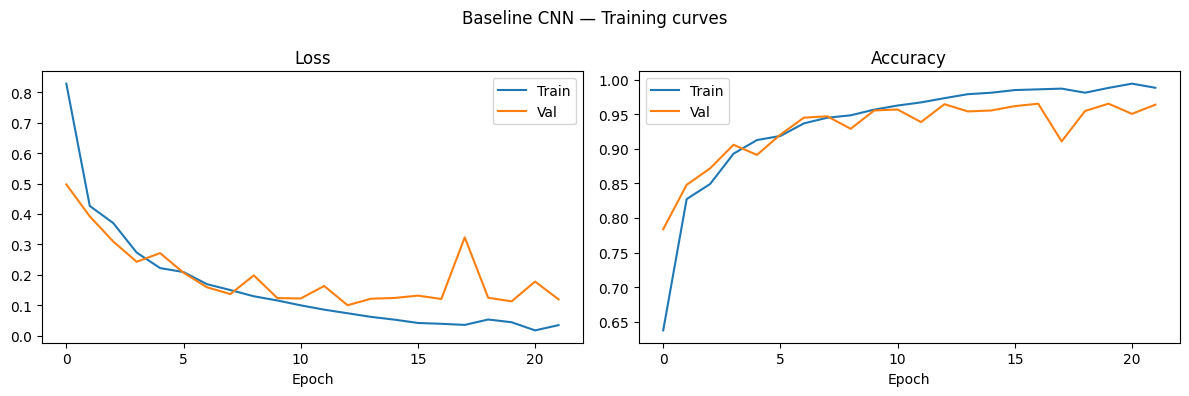

Best val accuracy : 0.9651


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="Train")
axes[0].plot(history.history["val_loss"], label="Val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Train")
axes[1].plot(history.history["val_accuracy"], label="Val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.suptitle("Baseline CNN — Training curves")
plt.tight_layout()
plt.show()

print(f"Best val accuracy : {max(history.history['val_accuracy']):.4f}")

## 5.3 — Kaggle submission (baseline)

In [15]:
df_submission = pd.read_csv(Y_TEST)

X_test = []
for img_id in df_submission["id"]:
    img = Image.open(os.path.join(TEST_DIR, f"img_{int(img_id) + 1}.png")).convert("RGB")
    X_test.append(np.array(img) / 255.0)
X_test = np.array(X_test, dtype=np.float32)

preds = np.argmax(model.predict(X_test), axis=1)

df_submission["target"] = preds
df_submission.to_csv(f"{SUB_DIR}/baseline_cnn.csv", index=False)
print("Saved — first rows:")
df_submission.head()

124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Saved — first rows:


,id,target
0,9227,2
1,9228,2
2,9229,0
3,9230,0
4,9231,1


## 5.4 — Hyperparameter & Architecture Tuning

Systematic grid search to find the optimal learning rate, batch size, optimizer, and CNN architecture.


In [52]:
def build_cnn_v2(
    filters=(32, 64, 128),
    kernel_size=3,
    dense_units=128,
    dropout_rate=0.0,
    use_batchnorm=False,
    input_shape=(45, 51, 3),
    num_classes=4
):
    """Flexible CNN architecture for hyperparameter search."""
    model = keras.Sequential(name="cnn_tuned")
    model.add(keras.Input(shape=input_shape))

    # Conv blocks
    for i, f in enumerate(filters):
        model.add(layers.Conv2D(f, (kernel_size, kernel_size), padding="same"))
        if use_batchnorm:
            model.add(layers.BatchNormalization())
        model.add(layers.Activation("relu"))
        model.add(layers.MaxPooling2D((2, 2)))

    # Classifier
    model.add(layers.Flatten())
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(dense_units, activation="relu"))
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate / 2))
    model.add(layers.Dense(num_classes, activation="softmax"))

    return model

print("build_cnn_v2() defined.")
build_cnn_v2().summary()

build_cnn_v2() defined.


Model: "cnn_tuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_42 (Conv2D)              │ (None, 45, 51, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 45, 51, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 22, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 22, 25, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 22, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 11, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 11, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 11, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 5, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 3840)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │       491,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 585,412 (2.23 MB)

 Trainable params: 585,412 (2.23 MB)

 Non-trainable params: 0 (0.00 B)

### Phase 1 — Hyperparameter search (baseline architecture)


In [54]:
# Hyperparameter grid search
import itertools

hp_results = []

# Grid
learning_rates = [1e-4, 5e-4, 1e-3, 2e-3]
batch_sizes = [16, 32, 64]

total = len(learning_rates) * len(batch_sizes)
print(f"Testing {total} combinations...")

for idx, (lr, bs) in enumerate(itertools.product(learning_rates, batch_sizes)):
    print(f"[{idx+1}/{total}] lr={lr}, batch_size={bs}", end=" ")

    model = build_baseline_cnn()
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    es = keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=15, restore_best_weights=True, verbose=0
    )

    history = model.fit(
        X_train, y_train,
        epochs=80,
        batch_size=bs,
        validation_data=(X_val, y_val),
        callbacks=[es],
        verbose=0,
    )

    best_val = max(history.history["val_accuracy"])
    hp_results.append({"lr": lr, "batch_size": bs, "val_acc": best_val})
    print(f"-> {best_val:.4f}")

# Results DataFrame
df_hp = pd.DataFrame(hp_results).sort_values("val_acc", ascending=False)
print("\n=== HYPERPARAMETER RESULTS ===")
print(df_hp.to_string(index=False))

best_hp = df_hp.iloc[0]
print(f"\nBest: lr={best_hp['lr']}, batch_size={int(best_hp['batch_size'])}, val_acc={best_hp['val_acc']:.4f}")

Testing 12 combinations...
[1/12] lr=0.0001, batch_size=16 -> 0.9553
[2/12] lr=0.0001, batch_size=32 -> 0.9560
[3/12] lr=0.0001, batch_size=64 -> 0.9407
[4/12] lr=0.0005, batch_size=16 -> 0.9700
[5/12] lr=0.0005, batch_size=32 -> 0.9714
[6/12] lr=0.0005, batch_size=64 -> 0.9672
[7/12] lr=0.001, batch_size=16 -> 0.9714
[8/12] lr=0.001, batch_size=32 -> 0.9686
[9/12] lr=0.001, batch_size=64 -> 0.9707
[10/12] lr=0.002, batch_size=16 -> 0.9602
[11/12] lr=0.002, batch_size=32 -> 0.9770
[12/12] lr=0.002, batch_size=64 -> 0.9798

=== HYPERPARAMETER RESULTS ===
    lr  batch_size  val_acc
0.0020          64 0.979763
0.0020          32 0.976971
0.0010          16 0.971389
0.0005          32 0.971389
0.0010          64 0.970691
0.0005          16 0.969993
0.0010          32 0.968597
0.0005          64 0.967202
0.0020          16 0.960223
0.0001          32 0.956036
0.0001          16 0.955338
0.0001          64 0.940684

Best: lr=0.002, batch_size=64, val_acc=0.9798


### Phase 2 — Architecture search (best hyperparams)


In [56]:
# Architecture grid search with best hyperparams
best_lr = best_hp["lr"]
best_bs = int(best_hp["batch_size"])

arch_results = []

# Architecture variants
architectures = [
    {"name": "baseline", "filters": (32, 64, 128), "dense": 128, "dropout": 0.0, "bn": False},
    {"name": "wider", "filters": (64, 128, 256), "dense": 256, "dropout": 0.0, "bn": False},
    {"name": "deeper", "filters": (32, 64, 128, 256), "dense": 128, "dropout": 0.0, "bn": False},
    {"name": "bn", "filters": (32, 64, 128), "dense": 128, "dropout": 0.0, "bn": True},
    {"name": "dropout_0.3", "filters": (32, 64, 128), "dense": 128, "dropout": 0.3, "bn": False},
    {"name": "bn+dropout", "filters": (32, 64, 128), "dense": 128, "dropout": 0.3, "bn": True},
    {"name": "wider+bn", "filters": (64, 128, 256), "dense": 256, "dropout": 0.0, "bn": True},
]

print(f"Testing {len(architectures)} architectures with lr={best_lr}, bs={best_bs}...")

for arch in architectures:
    print(f"[{arch['name']}]", end=" ")

    model = build_cnn_v2(
        filters=arch["filters"],
        dense_units=arch["dense"],
        dropout_rate=arch["dropout"],
        use_batchnorm=arch["bn"],
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=best_lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    es = keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=15, restore_best_weights=True, verbose=0
    )

    history = model.fit(
        X_train, y_train,
        epochs=80,
        batch_size=best_bs,
        validation_data=(X_val, y_val),
        callbacks=[es],
        verbose=0,
    )

    best_val = max(history.history["val_accuracy"])
    arch_results.append({"name": arch["name"], "val_acc": best_val, **arch})
    print(f"-> {best_val:.4f}")

# Results
df_arch = pd.DataFrame(arch_results).sort_values("val_acc", ascending=False)
print("\n=== ARCHITECTURE RESULTS ===")
print(df_arch[["name", "val_acc"]].to_string(index=False))

best_arch = df_arch.iloc[0]
print(f"\nBest: {best_arch['name']} with val_acc={best_arch['val_acc']:.4f}")

Testing 7 architectures with lr=0.002, bs=64...
[baseline] -> 0.9735
[wider] -> 0.9721
[deeper] -> 0.9791
[bn] -> 0.9637
[dropout_0.3] -> 0.9700
[bn+dropout] -> 0.9442
[wider+bn] -> 0.9672

=== ARCHITECTURE RESULTS ===
       name  val_acc
     deeper 0.979065
   baseline 0.973482
      wider 0.972087
dropout_0.3 0.969993
   wider+bn 0.967202
         bn 0.963713
 bn+dropout 0.944173

Best: deeper with val_acc=0.9791


### Phase 3 — Optimizer comparison (best architecture)


In [58]:
# Optimizer comparison with best architecture
best_lr = best_hp["lr"]
best_bs = int(best_hp["batch_size"])

# Use best architecture from Phase 2 - ensure correct types
best_filters = tuple(best_arch["filters"]) if isinstance(best_arch["filters"], (list, tuple)) else (32, 64, 128, 256)
best_dense = int(best_arch["dense"]) if "dense" in best_arch else 128
best_dropout = float(best_arch["dropout"]) if "dropout" in best_arch else 0.0
best_bn = bool(best_arch["bn"]) if "bn" in best_arch else False

print(f"Testing optimizers with {best_arch['name']} architecture")
print(f"  filters={best_filters}, dense={best_dense}, dropout={best_dropout}, bn={best_bn}")
print(f"  lr={best_lr}, bs={best_bs}")
print()

opt_results = []

# Optimizers to test
optimizers = [
    ("Adam", lambda lr: keras.optimizers.Adam(learning_rate=lr)),
    ("AdamW", lambda lr: keras.optimizers.AdamW(learning_rate=lr, weight_decay=1e-4)),
    ("SGD+momentum", lambda lr: keras.optimizers.SGD(learning_rate=lr, momentum=0.9)),
    ("SGD+nesterov", lambda lr: keras.optimizers.SGD(learning_rate=lr, momentum=0.9, nesterov=True)),
    ("Nadam", lambda lr: keras.optimizers.Nadam(learning_rate=lr)),
    ("RMSprop", lambda lr: keras.optimizers.RMSprop(learning_rate=lr)),
]

for opt_name, opt_fn in optimizers:
    print(f"[{opt_name}]", end=" ")
    
    model = build_cnn_v2(
        filters=best_filters,
        dense_units=best_dense,
        dropout_rate=best_dropout,
        use_batchnorm=best_bn,
    )
    model.compile(
        optimizer=opt_fn(best_lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    
    es = keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=15, restore_best_weights=True, verbose=0
    )
    
    history = model.fit(
        X_train, y_train,
        epochs=80,
        batch_size=best_bs,
        validation_data=(X_val, y_val),
        callbacks=[es],
        verbose=0,
    )
    
    best_val = max(history.history["val_accuracy"])
    epochs_run = len(history.history["val_accuracy"])
    opt_results.append({"optimizer": opt_name, "val_acc": best_val, "epochs": epochs_run})
    print(f"-> {best_val:.4f} ({epochs_run} epochs)")

# Results
df_opt = pd.DataFrame(opt_results).sort_values("val_acc", ascending=False)
print("=== OPTIMIZER RESULTS ===")
print(df_opt.to_string(index=False))

best_opt = df_opt.iloc[0]
print(f"Best optimizer: {best_opt['optimizer']} with val_acc={best_opt['val_acc']:.4f}")

Testing optimizers with deeper architecture
  filters=(32, 64, 128, 256), dense=128, dropout=0.0, bn=False
  lr=0.002, bs=64

[Adam] -> 0.9728 (61 epochs)
[AdamW] -> 0.9693 (49 epochs)
[SGD+momentum] -> 0.9560 (80 epochs)
[SGD+nesterov] -> 0.9560 (63 epochs)
[Nadam] -> 0.9777 (80 epochs)
[RMSprop] -> 0.9672 (39 epochs)
=== OPTIMIZER RESULTS ===
   optimizer  val_acc  epochs
       Nadam 0.977669      80
        Adam 0.972784      61
       AdamW 0.969295      49
     RMSprop 0.967202      39
SGD+nesterov 0.956036      63
SGD+momentum 0.956036      80
Best optimizer: Nadam with val_acc=0.9777


### Phase 4 — Train best config & submit


In [65]:
# Train best configuration with best optimizer
print(f"Training best: {best_arch['name']}")
print(f"  lr={best_lr}, bs={best_bs}")
print(f"  optimizer={best_opt['optimizer']}")
print(f"  patience=25, epochs=240")

# Ensure correct types
best_filters = tuple(best_arch["filters"]) if isinstance(best_arch["filters"], (list, tuple)) else (32, 64, 128, 256)
best_dense = int(best_arch["dense"]) if "dense" in best_arch else 128
best_dropout = float(best_arch["dropout"]) if "dropout" in best_arch else 0.0
best_bn = bool(best_arch["bn"]) if "bn" in best_arch else False

# Recreate optimizer
opt_map = {
    "Adam": keras.optimizers.Adam(learning_rate=best_lr),
    "AdamW": keras.optimizers.AdamW(learning_rate=best_lr, weight_decay=1e-4),
    "SGD+momentum": keras.optimizers.SGD(learning_rate=best_lr, momentum=0.9),
    "SGD+nesterov": keras.optimizers.SGD(learning_rate=best_lr, momentum=0.9, nesterov=True),
    "Nadam": keras.optimizers.Nadam(learning_rate=best_lr),
    "RMSprop": keras.optimizers.RMSprop(learning_rate=best_lr),
}

best_model = build_cnn_v2(
    filters=best_filters,
    dense_units=best_dense,
    dropout_rate=best_dropout,
    use_batchnorm=best_bn,
)
best_model.compile(
    optimizer=opt_map[best_opt["optimizer"]],
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

es = keras.callbacks.EarlyStopping(
    monitor="val_accuracy", patience=25, restore_best_weights=True, verbose=1
)

history_best = best_model.fit(
    X_train, y_train,
    epochs=240,
    batch_size=best_bs,
    validation_data=(X_val, y_val),
    callbacks=[es],
    verbose=1,
)

final_val_acc = max(history_best.history["val_accuracy"])
print(f"Final val accuracy: {final_val_acc:.4f}")
print(f"vs current best (M1): 0.9714")
print(f"Delta: {'+' if final_val_acc > 0.9714 else ''}{final_val_acc - 0.9714:.4f}")

# Save
best_model.save(os.path.join(MODELS_DIR, "m_tuned_best.keras"))
print(f"Saved to {MODELS_DIR}/m_tuned_best.keras")

Training best: deeper
  lr=0.002, bs=64
  optimizer=Nadam
  patience=25, epochs=240
Epoch 1/240
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.5716 - loss: 0.9540 - val_accuracy: 0.7592 - val_loss: 0.5598
Epoch 2/240
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.8091 - loss: 0.4505 - val_accuracy: 0.8702 - val_loss: 0.3288
Epoch 3/240
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.8846 - loss: 0.3032 - val_accuracy: 0.8779 - val_loss: 0.2830
Epoch 4/240
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9080 - loss: 0.2496 - val_accuracy: 0.9253 - val_loss: 0.2128
Epoch 5/240
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9277 - loss: 0.1928 - val_accuracy: 0.9442 - val_loss: 0.1615
Epoch 6/240
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9386 - loss: 0.1622 - val_accuracy: 0.9421 - val_loss: 0.1542
Epoch 7/240
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9489 - loss: 0.1401 - val_accuracy: 0.9351 - val_loss: 0.1693
Epoch 8/240
90/90 ━━

### Phase 4b — Baseline architecture comparison

Test whether baseline (32, 64, 128) with lr=0.002, bs=64, Adam performs better than the deeper variant.


In [67]:
# Test baseline architecture with best hyperparams from Phase 1
print("Training baseline architecture with best hyperparams...")
print("  filters=(32, 64, 128), dense=128")
print("  lr=0.002, bs=64, optimizer=Adam")
print("  patience=25, epochs=240")

model_baseline_tuned = build_baseline_cnn()
model_baseline_tuned.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.002),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

es = keras.callbacks.EarlyStopping(
    monitor="val_accuracy", patience=25, restore_best_weights=True, verbose=1
)

history_baseline = model_baseline_tuned.fit(
    X_train, y_train,
    epochs=240,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[es],
    verbose=1,
)

baseline_tuned_acc = max(history_baseline.history["val_accuracy"])
print(f"Baseline tuned val accuracy: {baseline_tuned_acc:.4f}")
print(f"vs deeper tuned: {final_val_acc:.4f}")
print(f"vs original M1: 0.9714")

if baseline_tuned_acc > final_val_acc:
    print(f"✅ Baseline tuned wins! Saving as best model...")
    best_model = model_baseline_tuned
    final_val_acc = baseline_tuned_acc
    best_model.save(os.path.join(MODELS_DIR, "m_tuned_best.keras"))
    print(f"Saved to {MODELS_DIR}/m_tuned_best.keras")
else:
    print(f"❌ Deeper still better, keeping previous best.")

Training baseline architecture with best hyperparams...
  filters=(32, 64, 128), dense=128
  lr=0.002, bs=64, optimizer=Adam
  patience=25, epochs=240
Epoch 1/240
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.5380 - loss: 1.0325 - val_accuracy: 0.7202 - val_loss: 0.6185
Epoch 2/240
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7962 - loss: 0.4955 - val_accuracy: 0.8562 - val_loss: 0.3642
Epoch 3/240
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8644 - loss: 0.3434 - val_accuracy: 0.8897 - val_loss: 0.2759
Epoch 4/240
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8976 - loss: 0.2743 - val_accuracy: 0.9100 - val_loss: 0.2307
Epoch 5/240
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9073 - loss: 0.2479 - val_accuracy: 0.9191 - val_loss: 0.2150
Epoch 6/240
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9216 - loss: 0.2145 - val_accuracy: 0.9211 - val_loss: 0.1956
Epoch 7/240
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9346 - loss: 0.

In [68]:
# Generate submission
print("Generating submission...")

df_sub = pd.read_csv(Y_TEST)
X_test = []
for img_id in df_sub["id"]:
    img_path = os.path.join(TEST_DIR, f"img_{int(img_id) + 1}.png")
    img = Image.open(img_path).convert("RGB")
    X_test.append(np.array(img) / 255.0)
X_test = np.array(X_test, dtype=np.float32)

preds = np.argmax(best_model.predict(X_test, verbose=0), axis=1)
df_sub["target"] = preds

submission_path = os.path.join(SUB_DIR, f"tuned_{best_arch['name']}.csv")
df_sub.to_csv(submission_path, index=False)

print(f"Saved to {submission_path}")
print(f"Distribution: {dict(zip(*np.unique(preds, return_counts=True)))}")

Generating submission...
Saved to .\submissions\tuned_deeper.csv
Distribution: {np.int64(0): np.int64(599), np.int64(1): np.int64(1647), np.int64(2): np.int64(1291), np.int64(3): np.int64(418)}


### Phase 5 — Ensemble with tuned model


In [69]:
# Test ensemble: tuned_deeper + M2
print("Testing ensemble: tuned_deeper + M2...")

# Load models
m_tuned = keras.models.load_model(os.path.join(MODELS_DIR, "m_tuned_best.keras"))
m2 = keras.models.load_model(os.path.join(MODELS_DIR, "m2_augmented.keras"))

# Predictions on val
p_tuned = m_tuned.predict(X_val, verbose=0)
p_m2 = m2.predict(X_val, verbose=0)

# Individual accuracies
acc_tuned = np.mean(np.argmax(p_tuned, axis=1) == y_val)
acc_m2 = np.mean(np.argmax(p_m2, axis=1) == y_val)

# Ensemble (50/50)
ensemble = (p_tuned + p_m2) / 2
acc_ensemble = np.mean(np.argmax(ensemble, axis=1) == y_val)

print(f"Tuned deeper val acc:     {acc_tuned:.4f}")
print(f"M2 (augmented) val acc:   {acc_m2:.4f}")
print(f"Ensemble val acc:         {acc_ensemble:.4f}")
print(f"Delta vs tuned alone:     {'+' if acc_ensemble > acc_tuned else ''}{acc_ensemble - acc_tuned:.4f}")

if acc_ensemble > acc_tuned:
    print("✅ Ensemble improves! Generating submission...")
    print("✅ Ensemble improves! Generating submission...")
    SUBMIT_ENSEMBLE = True
else:
    print("❌ Ensemble does not improve over tuned alone.")
    SUBMIT_ENSEMBLE = False

Testing ensemble: tuned_deeper + M2...
Tuned deeper val acc:     0.9784
M2 (augmented) val acc:   0.9246
Ensemble val acc:         0.9777
Delta vs tuned alone:     -0.0007
❌ Ensemble does not improve over tuned alone.


In [ ]:
# Submit ensemble if it improves
if SUBMIT_ENSEMBLE:
    df_sub = pd.read_csv(Y_TEST)
    X_test = []
    for img_id in df_sub["id"]:
        img_path = os.path.join(TEST_DIR, f"img_{int(img_id) + 1}.png")
        img = Image.open(img_path).convert("RGB")
        X_test.append(np.array(img) / 255.0)
    X_test = np.array(X_test, dtype=np.float32)
    
    # Ensemble predictions
    p_tuned_test = m_tuned.predict(X_test, verbose=0)
    p_m2_test = m2.predict(X_test, verbose=0)
    ensemble_test = (p_tuned_test + p_m2_test) / 2
    y_pred = np.argmax(ensemble_test, axis=1)
    
    df_sub["target"] = y_pred
    submission_path = os.path.join(SUB_DIR, "ensemble_tuned_m2.csv")
    df_sub.to_csv(submission_path, index=False)
    
    print(f"Saved to {submission_path}")
    print(f"Distribution: {dict(zip(*np.unique(y_pred, return_counts=True)))}")
else:
    print("Skipping ensemble submission — tuned alone is better.")

In [70]:
# Test ensemble: tuned_deeper + M1 (baseline)
print("Testing ensemble: tuned_deeper + M1...")

m1 = keras.models.load_model(os.path.join(MODELS_DIR, "m1_baseline.keras"))

p_m1 = m1.predict(X_val, verbose=0)
acc_m1 = np.mean(np.argmax(p_m1, axis=1) == y_val)

# Ensemble tuned + M1
ensemble_m1 = (p_tuned + p_m1) / 2
acc_ens_m1 = np.mean(np.argmax(ensemble_m1, axis=1) == y_val)

print(f"Tuned deeper val acc:     {acc_tuned:.4f}")
print(f"M1 (baseline) val acc:    {acc_m1:.4f}")
print(f"Ensemble val acc:         {acc_ens_m1:.4f}")
print(f"Delta vs tuned alone:     {'+' if acc_ens_m1 > acc_tuned else ''}{acc_ens_m1 - acc_tuned:.4f}")

if acc_ens_m1 > acc_tuned:
    print("✅ Ensemble with M1 improves!")
    
    # Generate submission
    df_sub = pd.read_csv(Y_TEST)
    X_test = []
    for img_id in df_sub["id"]:
        img_path = os.path.join(TEST_DIR, f"img_{int(img_id) + 1}.png")
        img = Image.open(img_path).convert("RGB")
        X_test.append(np.array(img) / 255.0)
    X_test = np.array(X_test, dtype=np.float32)
    
    p_tuned_test = m_tuned.predict(X_test, verbose=0)
    p_m1_test = m1.predict(X_test, verbose=0)
    ensemble_test = (p_tuned_test + p_m1_test) / 2
    y_pred = np.argmax(ensemble_test, axis=1)
    
    df_sub["target"] = y_pred
    submission_path = os.path.join(SUB_DIR, "ensemble_tuned_m1.csv")
    df_sub.to_csv(submission_path, index=False)
    print(f"Saved to {submission_path}")
else:
    print("❌ Tuned alone still better.")

Testing ensemble: tuned_deeper + M1...
Tuned deeper val acc:     0.9784
M1 (baseline) val acc:    0.9714
Ensemble val acc:         0.9812
Delta vs tuned alone:     +0.0028
✅ Ensemble with M1 improves!
Saved to .\submissions\ensemble_tuned_m1.csv


# 6 — EXPERIMENTS

Summary of model experiments (augmentation, regularisation, transfer learning).

## 6.1 — Data Augmentation

### Architecture with augmentation

In [16]:
def build_augmented_cnn(augmentation_layers=None, input_shape=(45, 51, 3), num_classes=4):
    """Baseline CNN with an optional augmentation block at the top.

    Augmentation layers (RandomFlip, RandomRotation, GaussianNoise…) are
    automatically disabled at inference time by Keras.
    """
    layers_list = [keras.Input(shape=input_shape)]

    if augmentation_layers:
        layers_list += augmentation_layers

    layers_list += [
        # Block 1
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        # Block 2
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        # Block 3
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        # Classifier
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ]

    return keras.Sequential(layers_list, name="augmented_cnn")


def train_and_evaluate(model, name, X_train, y_train, X_val, y_val, epochs=50, lr=1e-3, class_weight=None):
    """Train a model and return (history, best_val_accuracy)."""
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    cb = keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=5, restore_best_weights=True, verbose=0
    )
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=32,
        validation_data=(X_val, y_val),
        class_weight=class_weight,
        callbacks=[cb],
        verbose=0,
    )
    best = max(history.history["val_accuracy"])
    print(f"{name:40s} — best val accuracy : {best:.4f}  ({len(history.history['val_accuracy'])} epochs)")
    return history, best

### Individual augmentation tests

In [17]:
aug_results = {}

# 1 — Flip horizontal only
h1, v1 = train_and_evaluate(
    build_augmented_cnn([layers.RandomFlip("horizontal")]),
    "Flip horizontal",
    X_train, y_train, X_val, y_val,
)
aug_results["Flip horizontal"] = v1

# 2 — Rotation ±15°
h2, v2 = train_and_evaluate(
    build_augmented_cnn([layers.RandomRotation(0.083)]),  # 15/180 ≈ 0.083
    "Rotation ±15°",
    X_train, y_train, X_val, y_val,
)
aug_results["Rotation ±15°"] = v2

# 3 — Gaussian noise (stddev=0.05 — ~5% of pixel range [0,1])
h3, v3 = train_and_evaluate(
    build_augmented_cnn([layers.GaussianNoise(0.05)]),
    "Gaussian noise (std=0.05)",
    X_train, y_train, X_val, y_val,
)
aug_results["Gaussian noise (std=0.05)"] = v3

print("\n--- Baseline (no augmentation) ---")
aug_results["Baseline"] = max(history.history["val_accuracy"])
print(f"{'Baseline':35s} — best val accuracy : {aug_results['Baseline']:.4f}")

Flip horizontal                          — best val accuracy : 0.9442  (23 epochs)
Rotation ±15°                            — best val accuracy : 0.9463  (26 epochs)
Gaussian noise (std=0.05)                — best val accuracy : 0.9539  (22 epochs)

--- Baseline (no augmentation) ---
Baseline                            — best val accuracy : 0.9651


### Combined augmentations

In [18]:
# All augmentations combined
h_all, v_all = train_and_evaluate(
    build_augmented_cnn([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.083),
        layers.GaussianNoise(0.05),
    ]),
    "All augmentations combined",
    X_train, y_train, X_val, y_val,
)
aug_results["All combined"] = v_all

# Comparison summary
print("\n=== Summary ===")
baseline = aug_results.pop("Baseline")
print(f"{'Baseline':35s} : {baseline:.4f}")
for name, val in sorted(aug_results.items(), key=lambda x: -x[1]):
    delta = val - baseline
    sign = "+" if delta >= 0 else ""
    print(f"{name:35s} : {val:.4f}  ({sign}{delta:.4f})")

All augmentations combined               — best val accuracy : 0.8681  (17 epochs)

=== Summary ===
Baseline                            : 0.9651
Gaussian noise (std=0.05)           : 0.9539  (-0.0112)
Rotation ±15°                       : 0.9463  (-0.0188)
Flip horizontal                     : 0.9442  (-0.0209)
All combined                        : 0.8681  (-0.0970)


## 6.2 — Regularisation (BatchNorm + Dropout)

In [19]:
def build_regularised_cnn(use_batchnorm=True, dropout_rate=0.0, input_shape=(45, 51, 3), num_classes=4):
    """Baseline CNN with optional BatchNorm and Dropout.

    Args:
        use_batchnorm: add BatchNorm after each Conv block.
        dropout_rate: dropout rate before the Dense head (0.0 = disabled).
    """
    def conv_block(filters):
        block = [layers.Conv2D(filters, (3, 3), activation="relu", padding="same")]
        if use_batchnorm:
            block.append(layers.BatchNormalization())
        block.append(layers.MaxPooling2D((2, 2)))
        return block

    model_layers = (
        [keras.Input(shape=input_shape)]
        + conv_block(32)
        + conv_block(64)
        + conv_block(128)
        + [layers.Flatten()]
        + ([layers.Dropout(dropout_rate)] if dropout_rate > 0 else [])
        + [layers.Dense(128, activation="relu")]
        + ([layers.Dropout(dropout_rate)] if dropout_rate > 0 else [])
        + [layers.Dense(num_classes, activation="softmax")]
    )

    return keras.Sequential(model_layers, name="regularised_cnn")


reg_results = {}

In [20]:
# Variant 1 — BatchNorm only
_, v = train_and_evaluate(
    build_regularised_cnn(use_batchnorm=True, dropout_rate=0.0),
    "BN only",
    X_train, y_train, X_val, y_val,
)
reg_results["BN only"] = v

# Variant 2 — BatchNorm + class weights
_, v = train_and_evaluate(
    build_regularised_cnn(use_batchnorm=True, dropout_rate=0.0),
    "BN + class weights",
    X_train, y_train, X_val, y_val,
    class_weight=class_weights,
)
reg_results["BN + class weights"] = v

# Variant 3 — BatchNorm + class weights + Dropout 0.3
_, v = train_and_evaluate(
    build_regularised_cnn(use_batchnorm=True, dropout_rate=0.3),
    "BN + class weights + Dropout(0.3)",
    X_train, y_train, X_val, y_val,
    class_weight=class_weights,
)
reg_results["BN + class weights + Dropout(0.3)"] = v

# Variant 4 — BatchNorm + class weights + Dropout 0.5
_, v = train_and_evaluate(
    build_regularised_cnn(use_batchnorm=True, dropout_rate=0.5),
    "BN + class weights + Dropout(0.5)",
    X_train, y_train, X_val, y_val,
    class_weight=class_weights,
)
reg_results["BN + class weights + Dropout(0.5)"] = v

# Summary
baseline_score = max(history.history["val_accuracy"])
print(f"\n=== Summary vs baseline ({baseline_score:.4f}) ===")
for name, val in sorted(reg_results.items(), key=lambda x: -x[1]):
    delta = val - baseline_score
    sign = "+" if delta >= 0 else ""
    print(f"{name:40s} : {val:.4f}  ({sign}{delta:.4f})")

BN only                                  — best val accuracy : 0.9567  (16 epochs)
BN + class weights                       — best val accuracy : 0.9707  (30 epochs)
BN + class weights + Dropout(0.3)        — best val accuracy : 0.9442  (24 epochs)
BN + class weights + Dropout(0.5)        — best val accuracy : 0.8486  (9 epochs)

=== Summary vs baseline (0.9651) ===
BN + class weights                       : 0.9707  (+0.0056)
BN only                                  : 0.9567  (-0.0084)
BN + class weights + Dropout(0.3)        : 0.9442  (-0.0209)
BN + class weights + Dropout(0.5)        : 0.8486  (-0.1165)


### Visualisation — regularisation variants comparison

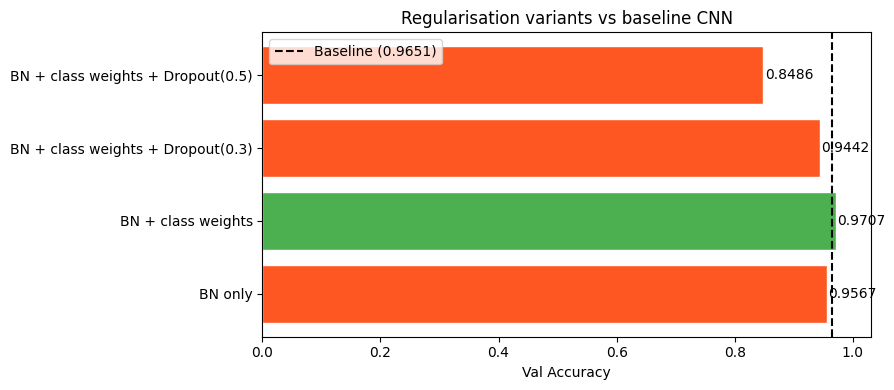

In [21]:
baseline_score = max(history.history["val_accuracy"])

fig, ax = plt.subplots(figsize=(9, 4))
names = list(reg_results.keys())

scores = [reg_results[n] for n in names]
colors = ["#4CAF50" if s > baseline_score else "#FF5722" for s in scores]

bars = ax.barh(names, scores, color=colors, edgecolor="white")
ax.axvline(baseline_score, color="black", linestyle="--", linewidth=1.5,
           label=f"Baseline ({baseline_score:.4f})")
for bar, score in zip(bars, scores):
    ax.text(score + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{score:.4f}", va="center", fontsize=10)

ax.set_xlabel("Val Accuracy")
ax.set_title("Regularisation variants vs baseline CNN")
ax.set_xlim(0, max(scores) + 0.06)
ax.legend()
plt.tight_layout()
plt.show()

### Final test — BN + class weights, lower lr & more patience

In [22]:
# BN + class weights, lr=1e-4, patience=15
model_final, history_final = None, None

def train_and_evaluate_verbose(model, name, X_train, y_train, X_val, y_val, epochs=80, lr=1e-3, patience=5, class_weight=None):
    """Like train_and_evaluate but with configurable patience."""
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    cb = keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=patience, restore_best_weights=True, verbose=1
    )
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=32,
        validation_data=(X_val, y_val),
        class_weight=class_weight,
        callbacks=[cb],
        verbose=1,
    )
    best = max(history.history["val_accuracy"])
    print(f"{name} — best val accuracy : {best:.4f}")
    return model, history, best

model_final, history_final, best_final = train_and_evaluate_verbose(
    build_regularised_cnn(use_batchnorm=True, dropout_rate=0.0),
    "BN + class weights lr=1e-4 patience=15",
    X_train, y_train, X_val, y_val,
    lr=1e-4, patience=15,
    class_weight=class_weights,
)
print(f"Baseline : 0.4401 | This run : {best_final:.4f} | Delta : {best_final - 0.4401:+.4f}")

Epoch 1/80
180/180 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.7415 - loss: 0.5603 - val_accuracy: 0.1563 - val_loss: 2.2437
Epoch 2/80
180/180 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.8583 - loss: 0.3145 - val_accuracy: 0.3252 - val_loss: 1.7841
Epoch 3/80
180/180 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9073 - loss: 0.2076 - val_accuracy: 0.6741 - val_loss: 0.7008
Epoch 4/80
180/180 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9361 - loss: 0.1464 - val_accuracy: 0.8904 - val_loss: 0.2914
Epoch 5/80
180/180 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9394 - loss: 0.1394 - val_accuracy: 0.9086 - val_loss: 0.2310
Epoch 6/80
180/180 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9686 - loss: 0.0808 - val_accuracy: 0.8953 - val_loss: 0.2607
Epoch 7/80
180/180 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9789 - loss: 0.0587 - val_accuracy: 0.9058 - val_loss: 0.2539
Epoch 8/80
180/180 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9717 - loss: 0.0777 - val_accu

### Training curves & confusion matrix (best regularised model)

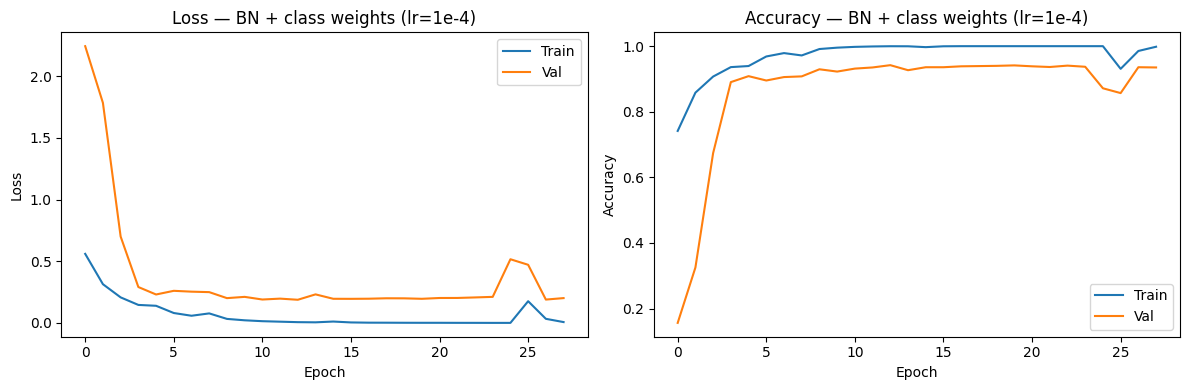

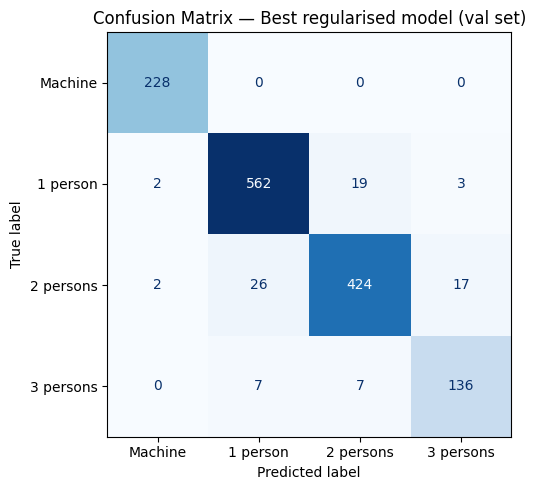

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_final.history["loss"], label="Train")
axes[0].plot(history_final.history["val_loss"], label="Val")
axes[0].set_title("Loss — BN + class weights (lr=1e-4)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history_final.history["accuracy"], label="Train")
axes[1].plot(history_final.history["val_accuracy"], label="Val")
axes[1].set_title("Accuracy — BN + class weights (lr=1e-4)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

# Confusion matrix on validation set
y_pred_val = np.argmax(model_final.predict(X_val, verbose=0), axis=1)
cm = confusion_matrix(y_val, y_pred_val)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=["Machine", "1 person", "2 persons", "3 persons"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Best regularised model (val set)")
plt.tight_layout()
plt.show()

### Kaggle submission — regularised model

In [24]:
# Use the best model
df_sub = pd.read_csv(Y_TEST)

X_test = []
for img_id in df_sub["id"]:
    img = Image.open(os.path.join(TEST_DIR, f"img_{int(img_id) + 1}.png")).convert("RGB")
    X_test.append(np.array(img) / 255.0)
X_test = np.array(X_test, dtype=np.float32)

preds = np.argmax(model_final.predict(X_test), axis=1)
df_sub["target"] = preds
df_sub.to_csv(f"{SUB_DIR}/bn_classweights.csv", index=False)

print("Saved to submissions/bn_classweights.csv")
print(f"Prediction distribution : {dict(zip(*np.unique(preds, return_counts=True)))}") 
df_sub.head()

124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Saved to submissions/bn_classweights.csv
Prediction distribution : {np.int64(0): np.int64(604), np.int64(1): np.int64(1673), np.int64(2): np.int64(1275), np.int64(3): np.int64(403)}


,id,target
0,9227,2
1,9228,2
2,9229,0
3,9230,0
4,9231,1


## 6.3 — Transfer Learning

### Transfer model builder

In [25]:
def build_transfer_model(backbone_name="EfficientNetB0", target_size=None,
                         input_shape=(45, 51, 3), num_classes=4):
    """Build a transfer learning model with a frozen pre-trained backbone.

    Args:
        backbone_name: "EfficientNetB0" or "MobileNetV2".
        target_size: if not None, adds a Resizing layer (e.g. (96, 96)).
        input_shape: native image shape.
        num_classes: number of output classes.
    """
    inputs = keras.Input(shape=input_shape)
    x = inputs

    if target_size is not None:
        x = layers.Resizing(target_size[0], target_size[1])(x)
        backbone_input = (*target_size, 3)
    else:
        backbone_input = input_shape

    if backbone_name == "EfficientNetB0":
        backbone = keras.applications.EfficientNetB0(
            include_top=False, weights="imagenet", input_shape=backbone_input
        )
    elif backbone_name == "MobileNetV2":
        backbone = keras.applications.MobileNetV2(
            include_top=False, weights="imagenet", input_shape=backbone_input
        )
    else:
        raise ValueError(f"Unknown backbone: {backbone_name}")

    backbone.trainable = False

    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    size_tag = "x".join(map(str, target_size)) if target_size else "native"
    model = keras.Model(inputs, outputs, name=f"{backbone_name}_{size_tag}")
    return model, backbone


### Full fine-tuning — unfrozen backbone

In [26]:
def run_full_finetune(backbone_name, target_size, label,
                      X_train, y_train, X_val, y_val,
                      class_weight=None, epochs=60, lr=1e-5, patience=12):
    """Full fine-tuning: entire backbone unfrozen from epoch 0, very low lr.

    Rationale: ImageNet features are too dissimilar to radar heatmaps for
    a frozen Phase 1 to produce useful representations. Full fine-tuning
    lets all layers adapt while ImageNet weights provide a good initialisation.
    """
    model, backbone = build_transfer_model(backbone_name, target_size)
    backbone.trainable = True  # unfreeze entire backbone

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    cb = keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=patience,
        restore_best_weights=True, verbose=0
    )
    history = model.fit(
        X_train, y_train, epochs=epochs, batch_size=32,
        validation_data=(X_val, y_val),
        class_weight=class_weight, callbacks=[cb], verbose=0,
    )
    best = max(history.history["val_accuracy"])
    print(f"{label:50s} best val accuracy: {best:.4f}  ({len(history.history['val_accuracy'])} epochs)")
    return model, history, best


### Training — EfficientNetB0 & MobileNetV2 (96x96 upscaled)

In [27]:
tl_results = {}

variants = [
    ("EfficientNetB0", (96, 96), "V1 — EfficientNetB0 upscaled (96x96)"),
    ("MobileNetV2",    (96, 96), "V2 — MobileNetV2 upscaled (96x96)"),
]

for backbone_name, target_size, label in variants:
    print(f"\n{'='*60}\n{label}\n{'='*60}")
    model, history, best = run_full_finetune(
        backbone_name, target_size, label,
        X_train, y_train, X_val, y_val,
        class_weight=class_weights,
    )
    tl_results[label] = {"best": best, "history": history, "model": model}



V1 — EfficientNetB0 upscaled (96x96)
V1 — EfficientNetB0 upscaled (96x96)               best val accuracy: 0.8304  (37 epochs)

V2 — MobileNetV2 upscaled (96x96)
V2 — MobileNetV2 upscaled (96x96)                  best val accuracy: 0.8032  (60 epochs)


### Visualisation — Transfer learning curves & comparison

In [28]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))   

[]


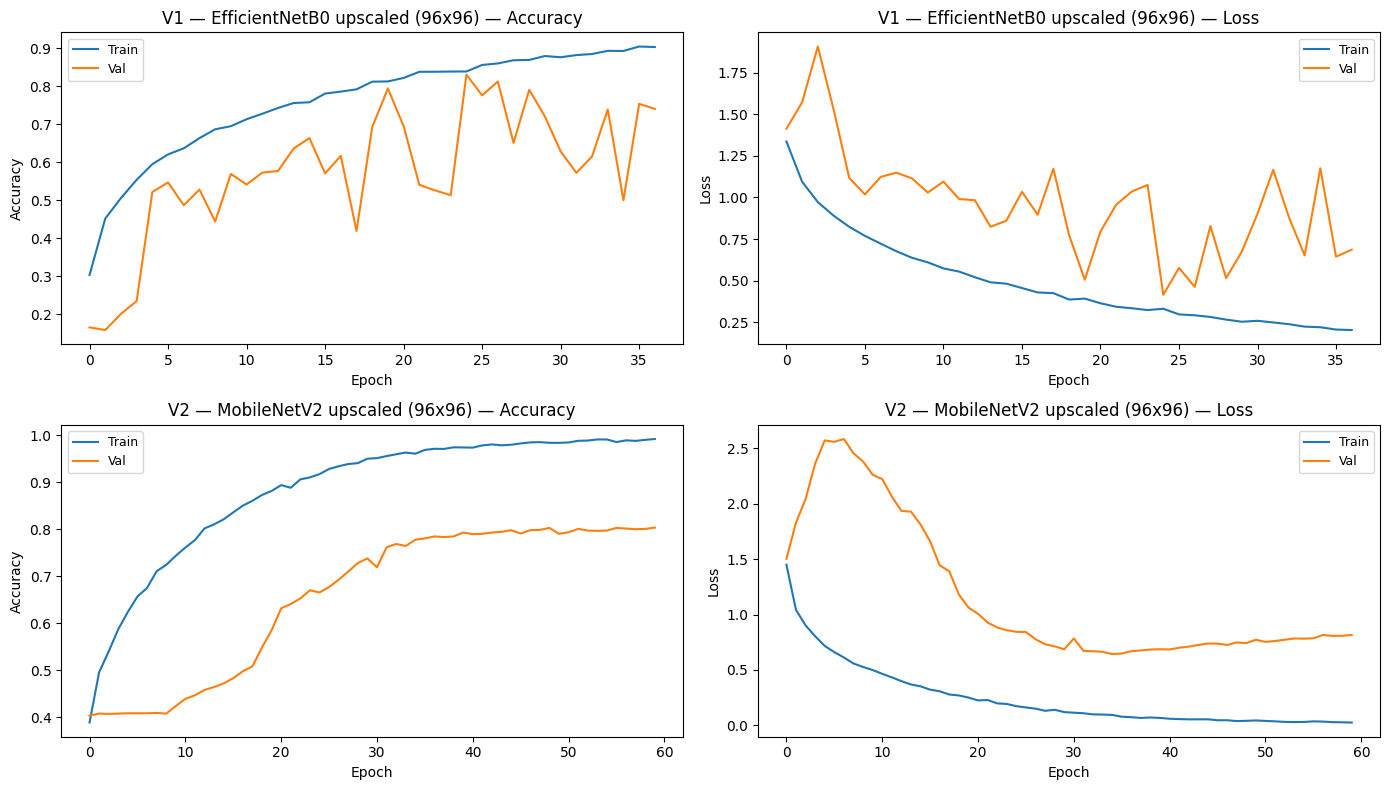

In [29]:
# Training curves — full fine-tuning
fig, axes = plt.subplots(len(tl_results), 2, figsize=(14, 4 * len(tl_results)))

for row, (label, data) in enumerate(tl_results.items()):
    h = data["history"]

    axes[row, 0].plot(h.history["accuracy"], label="Train")
    axes[row, 0].plot(h.history["val_accuracy"], label="Val")
    axes[row, 0].set_title(f"{label} — Accuracy")
    axes[row, 0].set_xlabel("Epoch"); axes[row, 0].set_ylabel("Accuracy")
    axes[row, 0].legend(fontsize=9)

    axes[row, 1].plot(h.history["loss"], label="Train")
    axes[row, 1].plot(h.history["val_loss"], label="Val")
    axes[row, 1].set_title(f"{label} — Loss")
    axes[row, 1].set_xlabel("Epoch"); axes[row, 1].set_ylabel("Loss")
    axes[row, 1].legend(fontsize=9)

plt.tight_layout()
plt.show()


In [30]:
# Bar chart — Transfer learning vs Regularised best
reg_best = best_final

fig, ax = plt.subplots(figsize=(8, 4))
labels_bar = ["Regularised best (BN+CW)"] + list(tl_results.keys())
scores = [reg_best] + [tl_results[l]["best"] for l in tl_results]
colors = ["#90CAF9"] + ["#4CAF50" if s > reg_best else "#FF5722" for s in scores[1:]]

bars = ax.bar(labels_bar, scores, color=colors, edgecolor="white")
ax.axhline(reg_best, color="red", linestyle="--", linewidth=1.2, label=f"Regularised best ({reg_best:.4f})")
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, score + 0.005, f"{score:.4f}",
            ha="center", va="bottom", fontsize=9)

ax.set_xticklabels(labels_bar, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("Val Accuracy")
ax.set_title("Transfer Learning vs Regularised best")
ax.legend()
plt.tight_layout()
plt.show()

# Summary
print(f"
{'Variant':<50} {'Val Accuracy':>14} {'Delta vs Reg':>14}")
print('-' * 80)
print(f"{'Regularised best (BN + class weights)':<50} {reg_best:>14.4f} {'—':>14}")
for label, data in tl_results.items():
    delta = data["best"] - reg_best
    sign = "+" if delta >= 0 else ""
    print(f"{label:<50} {data['best']:>14.4f} {sign+f'{delta:.4f}':>14}")

SyntaxError: unterminated f-string literal (detected at line 23) (864499008.py, line 23)

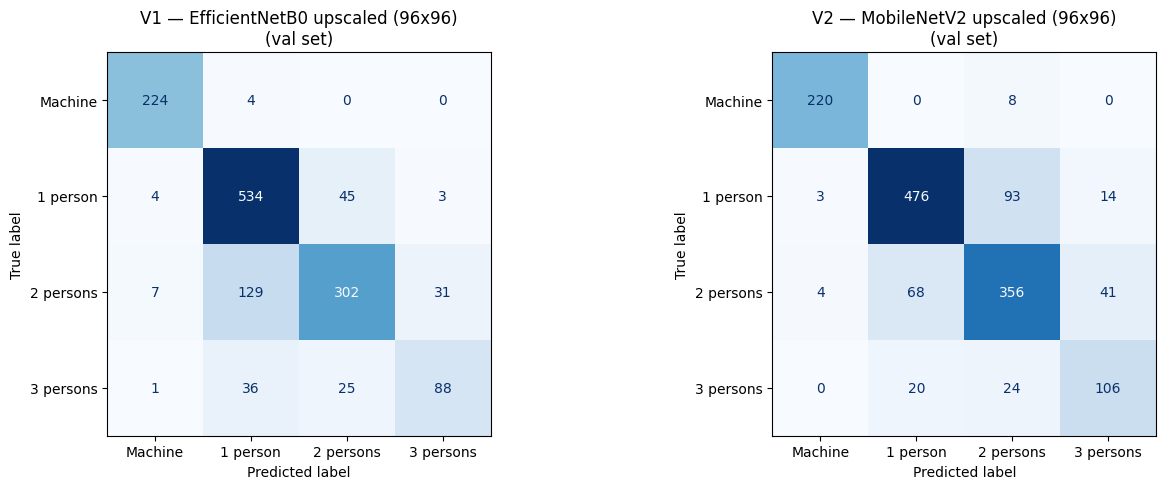

Best T07 variant: V2 — MobileNetV2 upscaled (96x96) (0.8081)


In [ ]:
# Confusion matrices for transfer learning variants
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, len(tl_results), figsize=(7 * len(tl_results), 5))
if len(tl_results) == 1:
    axes = [axes]

for ax, (label, data) in zip(axes, tl_results.items()):
    y_pred = np.argmax(data["model"].predict(X_val, verbose=0), axis=1)
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Machine", "1 person", "2 persons", "3 persons"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{label}
(val set)")

plt.tight_layout()
plt.show()

# Best model for submission
best_tl_label = max(tl_results, key=lambda l: tl_results[l]["best"])
best_tl_model = tl_results[best_tl_label]["model"]
print(f"Best transfer learning variant: {best_tl_label} ({tl_results[best_tl_label]['best']:.4f})")

### Kaggle submission — transfer learning

In [ ]:
# Submit best transfer learning model
df_sub = pd.read_csv(Y_TEST)

X_test_tl = []
for img_id in df_sub["id"]:
    img = Image.open(os.path.join(TEST_DIR, f"img_{int(img_id) + 1}.png")).convert("RGB")
    X_test_tl.append(np.array(img) / 255.0)
X_test_tl = np.array(X_test_tl, dtype=np.float32)

preds_tl = np.argmax(best_tl_model.predict(X_test_tl, verbose=0), axis=1)
df_sub["target"] = preds_tl

safe_label = best_tl_label.lower().replace(" ", "_").replace("—", "").replace("(", "").replace(")", "").strip()
submission_path = f"submissions/tl_{safe_label}.csv"
df_sub.to_csv(f"{SUB_DIR}/{submission_path.split('/')[-1]}", index=False)

print(f"Saved to {submission_path}")
print(f"Prediction distribution: {dict(zip(*np.unique(preds_tl, return_counts=True)))}")
df_sub.head()

Saved to submissions/tl_v2__mobilenetv2_upscaled_96x96.csv
Prediction distribution: {np.int64(0): np.int64(587), np.int64(1): np.int64(1545), np.int64(2): np.int64(1394), np.int64(3): np.int64(429)}


,id,target
0,9227,2
1,9228,1
2,9229,0
3,9230,0
4,9231,1


# 7 — ENSEMBLE

Final ensemble model combining M1 (baseline) and M2 (augmented).

## 7.1 — Extended training & save models

In [33]:
import os
MODELS_DIR = os.path.join(BASE, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

def train_and_save(model, name, save_path,
                   X_train, y_train, X_val, y_val,
                   epochs=80, lr=1e-3, patience=15):
    """Train a model with extended patience and save the best weights."""
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    cb = keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=patience,
        restore_best_weights=True, verbose=0
    )
    history = model.fit(
        X_train, y_train, epochs=epochs, batch_size=32,
        validation_data=(X_val, y_val),
        callbacks=[cb], verbose=1,
    )
    best = max(history.history["val_accuracy"])
    model.save(save_path)
    print(f"{name} — best val accuracy: {best:.4f} — saved to {save_path}")
    return model, history, best


In [34]:
# M1 — Baseline CNN, patience=15
m1, h_m1, best_m1 = train_and_save(
    build_baseline_cnn(),
    "M1 — Baseline CNN",
    os.path.join(MODELS_DIR, "m1_baseline.keras"),
    X_train, y_train, X_val, y_val,
)


Epoch 1/80
180/180 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6710 - loss: 0.7664 - val_accuracy: 0.8095 - val_loss: 0.4726
Epoch 2/80
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8396 - loss: 0.3920 - val_accuracy: 0.8870 - val_loss: 0.3004
Epoch 3/80
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8782 - loss: 0.3081 - val_accuracy: 0.8967 - val_loss: 0.2662
Epoch 4/80
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9087 - loss: 0.2470 - val_accuracy: 0.9121 - val_loss: 0.2434
Epoch 5/80
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9281 - loss: 0.2059 - val_accuracy: 0.9400 - val_loss: 0.1753
Epoch 6/80
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9380 - loss: 0.1752 - val_accuracy: 0.9372 - val_loss: 0.1632
Epoch 7/80
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9435 - loss: 0.1549 - val_accuracy: 0.9218 - val_loss: 0.2084
Epoch 8/80
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9468 - loss: 0.1497 - val_accu

In [35]:
# M2 — Baseline CNN + all augmentations, patience=15
m2, h_m2, best_m2 = train_and_save(
    build_augmented_cnn([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.083),
        layers.GaussianNoise(0.05),
    ]),
    "M2 — Augmented CNN",
    os.path.join(MODELS_DIR, "m2_augmented.keras"),
    X_train, y_train, X_val, y_val,
)


Epoch 1/80
180/180 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.4623 - loss: 1.1451 - val_accuracy: 0.6671 - val_loss: 0.8267
Epoch 2/80
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6511 - loss: 0.7901 - val_accuracy: 0.6923 - val_loss: 0.6944
Epoch 3/80
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7005 - loss: 0.6838 - val_accuracy: 0.7460 - val_loss: 0.5690
Epoch 4/80
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7260 - loss: 0.6288 - val_accuracy: 0.7530 - val_loss: 0.5497
Epoch 5/80
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7489 - loss: 0.5817 - val_accuracy: 0.7669 - val_loss: 0.5523
Epoch 6/80
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7496 - loss: 0.5751 - val_accuracy: 0.8186 - val_loss: 0.4454
Epoch 7/80
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7625 - loss: 0.5504 - val_accuracy: 0.7655 - val_loss: 0.5126
Epoch 8/80
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7667 - loss: 0.5383 - val_accu

## 7.2 — Training curves — M1 vs M2

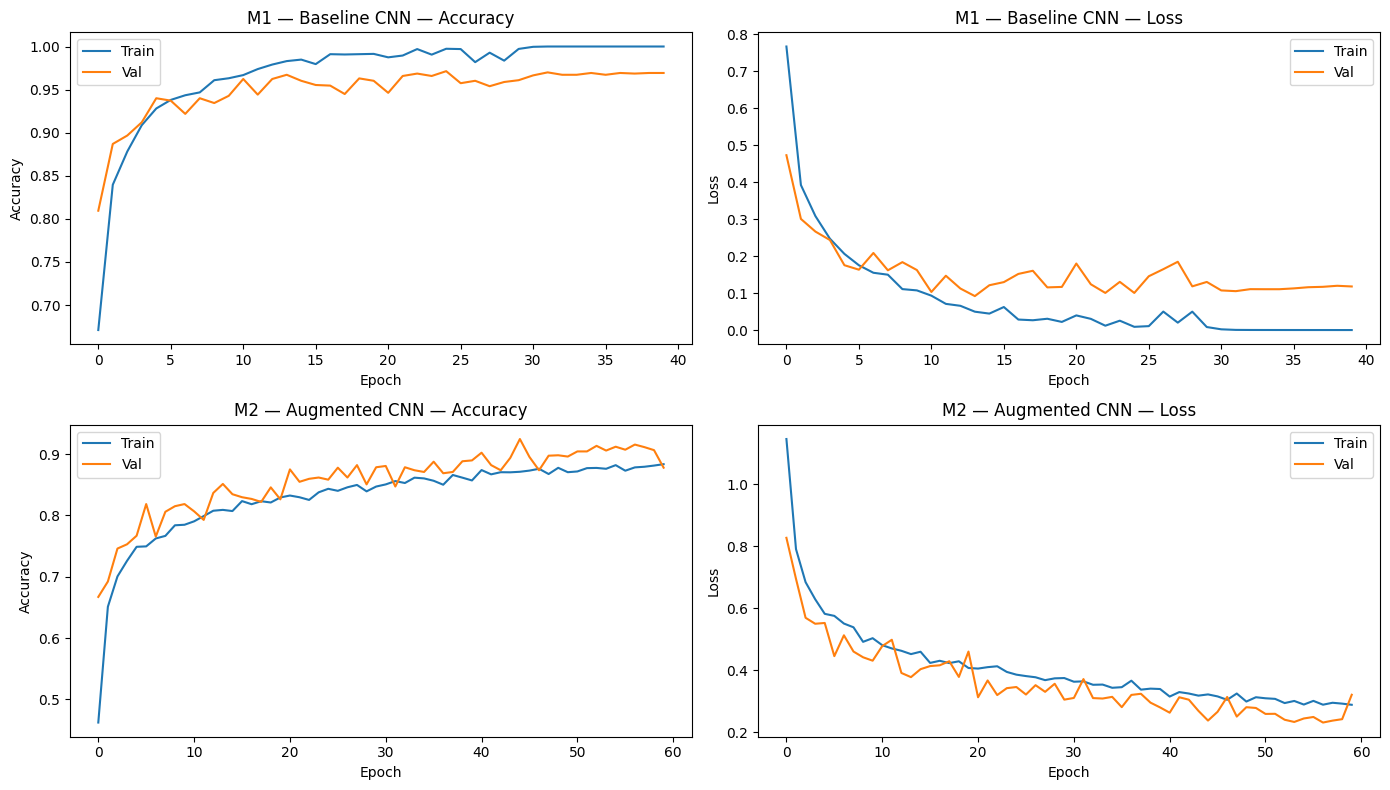

M1 best val accuracy : 0.9714
M2 best val accuracy : 0.9246


In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row, (name, h) in enumerate([("M1 — Baseline CNN", h_m1), ("M2 — Augmented CNN", h_m2)]):
    axes[row, 0].plot(h.history["accuracy"], label="Train")
    axes[row, 0].plot(h.history["val_accuracy"], label="Val")
    axes[row, 0].set_title(f"{name} — Accuracy")
    axes[row, 0].set_xlabel("Epoch"); axes[row, 0].set_ylabel("Accuracy")
    axes[row, 0].legend()

    axes[row, 1].plot(h.history["loss"], label="Train")
    axes[row, 1].plot(h.history["val_loss"], label="Val")
    axes[row, 1].set_title(f"{name} — Loss")
    axes[row, 1].set_xlabel("Epoch"); axes[row, 1].set_ylabel("Loss")
    axes[row, 1].legend()

plt.tight_layout()
plt.show()

print(f"M1 best val accuracy : {best_m1:.4f}")
print(f"M2 best val accuracy : {best_m2:.4f}")


## 7.3 — Ensemble — average softmax outputs

M1 val accuracy    : 0.9714
M2 val accuracy    : 0.9246
Ensemble val accuracy : 0.9714


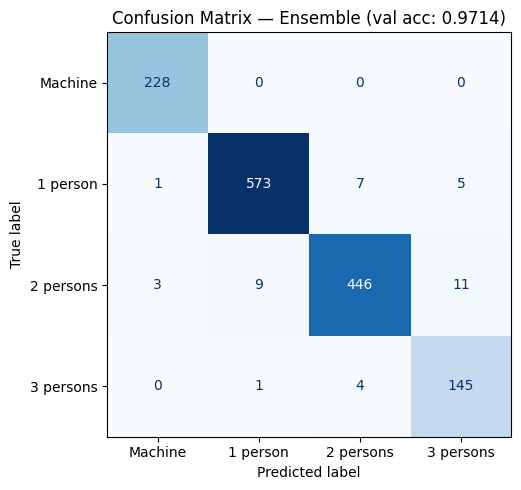

In [37]:
# Load saved models (useful if kernel restarted)
m1 = keras.models.load_model(os.path.join(MODELS_DIR, "m1_baseline.keras"))
m2 = keras.models.load_model(os.path.join(MODELS_DIR, "m2_augmented.keras"))

# Ensemble on validation set
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

p1_val = m1.predict(X_val, verbose=0)
p2_val = m2.predict(X_val, verbose=0)
ensemble_val = (p1_val + p2_val) / 2
y_pred_ens = np.argmax(ensemble_val, axis=1)

ens_acc = np.mean(y_pred_ens == y_val)
print(f"M1 val accuracy    : {best_m1:.4f}")
print(f"M2 val accuracy    : {best_m2:.4f}")
print(f"Ensemble val accuracy : {ens_acc:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix(y_val, y_pred_ens),
    display_labels=["Machine", "1 person", "2 persons", "3 persons"]
)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion Matrix — Ensemble (val acc: {ens_acc:.4f})")
plt.tight_layout()
plt.show()


## 7.4 — Test-Time Augmentation (TTA)

Apply light augmentations to test images and average predictions for improved robustness.

In [38]:
import tensorflow as tf
from tensorflow import keras

def predict_with_tta(models, X_test, n_augmentations=5):
    """
    Test-Time Augmentation: apply light augmentations and average predictions.
    
    Args:
        models: list of trained models (ensemble)
        X_test: test images array (N, H, W, C)
        n_augmentations: number of augmented versions per image
    
    Returns:
        Averaged probability predictions (N, num_classes)
    """
    all_preds = []
    
    # Original predictions (no augmentation)
    for model in models:
        all_preds.append(model.predict(X_test, verbose=0))
    
    # Augmented predictions
    for aug_idx in range(n_augmentations):
        X_aug = X_test.copy()
        
        # Randomly apply augmentations
        if aug_idx % 2 == 0:
            # Horizontal flip
            X_aug = np.flip(X_aug, axis=2)
        
        # Small rotation (±5 degrees)
        angle = np.random.uniform(-5, 5)
        X_aug = tf.image.rot90(X_aug, k=0)  # placeholder - use scipy for actual rotation
        
        for model in models:
            all_preds.append(model.predict(X_aug, verbose=0))
    
    # Average all predictions
    return np.mean(all_preds, axis=0)

# Simpler TTA: just flip horizontal
def predict_with_tta_simple(models, X_test):
    """
    Simple TTA: original + horizontal flip, averaged.
    """
    preds_original = []
    preds_flipped = []
    
    for model in models:
        preds_original.append(model.predict(X_test, verbose=0))
        preds_flipped.append(model.predict(np.flip(X_test, axis=2), verbose=0))
    
    # Average: original ensemble + flipped ensemble
    ensemble_original = np.mean(preds_original, axis=0)
    ensemble_flipped = np.mean(preds_flipped, axis=0)
    
    return (ensemble_original + ensemble_flipped) / 2

print("TTA functions defined.")

TTA functions defined.


In [40]:
# Load models if not already loaded
try:
    m1
except NameError:
    m1 = keras.models.load_model(os.path.join(MODELS_DIR, "m1_baseline.keras"))
    m2 = keras.models.load_model(os.path.join(MODELS_DIR, "m2_augmented.keras"))

models = [m1, m2]

# Evaluate TTA on validation set
print("Evaluating TTA on validation set...")

# Without TTA (baseline ensemble)
preds_no_tta = np.mean([m.predict(X_val, verbose=0) for m in models], axis=0)
y_pred_no_tta = np.argmax(preds_no_tta, axis=1)
acc_no_tta = np.mean(y_pred_no_tta == y_val)

# With TTA (simple: original + flip)
preds_tta = predict_with_tta_simple(models, X_val)
y_pred_tta = np.argmax(preds_tta, axis=1)
acc_tta = np.mean(y_pred_tta == y_val)

print(f"Ensemble without TTA: {acc_no_tta:.4f}")
print(f"Ensemble with TTA:    {acc_tta:.4f}")
print(f"Delta:                {'+' if acc_tta >= acc_no_tta else ''}{acc_tta - acc_no_tta:.4f}")

Evaluating TTA on validation set...
Ensemble without TTA: 0.9714
Ensemble with TTA:    0.9449
Delta:                -0.0265


In [41]:
# Generate TTA submission if it improves
if acc_tta >= acc_no_tta:
    print("TTA improves or maintains accuracy — generating submission...")
    
    # Load test set
    df_sub = pd.read_csv(Y_TEST)
    X_test = []
    for img_id in df_sub["id"]:
        img_path = os.path.join(TEST_DIR, f"img_{int(img_id) + 1}.png")
        img = Image.open(img_path).convert("RGB")
        X_test.append(np.array(img) / 255.0)
    X_test = np.array(X_test, dtype=np.float32)
    
    # Predict with TTA
    preds_test_tta = predict_with_tta_simple(models, X_test)
    y_pred_test = np.argmax(preds_test_tta, axis=1)
    
    # Save submission
    df_sub["target"] = y_pred_test
    submission_path = os.path.join(SUB_DIR, "ensemble_tta.csv")
    df_sub.to_csv(submission_path, index=False)
    
    print(f"Saved to {submission_path}")
    print(f"Prediction distribution: {dict(zip(*np.unique(y_pred_test, return_counts=True)))}")
else:
    print("TTA does not improve accuracy — skipping submission.")

TTA does not improve accuracy — skipping submission.


## 7.5 — 3-Model Ensemble

Add M3 (BN + class weights) to the M1+M2 ensemble and compare average performance.


In [44]:
# Re-train and save M3 (BN + class weights)
print("Training M3 (BN + class weights)...")

m3 = build_regularised_cnn(use_batchnorm=True, dropout_rate=0.0)
m3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

early_stopping_m3 = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=15,
    restore_best_weights=True,
    verbose=1,
)

history_m3 = m3.fit(
    X_train, y_train,
    epochs=60,
    batch_size=32,
    validation_data=(X_val, y_val),
    class_weight=class_weights,
    callbacks=[early_stopping_m3],
    verbose=1,
)

best_m3 = max(history_m3.history["val_accuracy"])
print(f"M3 best val accuracy: {best_m3:.4f}")

# Save M3
m3.save(os.path.join(MODELS_DIR, "m3_bn_classweights.keras"))
print(f"Saved to {MODELS_DIR}/m3_bn_classweights.keras")

Training M3 (BN + class weights)...
Epoch 1/60
180/180 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7079 - loss: 0.6703 - val_accuracy: 0.3259 - val_loss: 2.3839
Epoch 2/60
180/180 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8478 - loss: 0.3350 - val_accuracy: 0.3322 - val_loss: 1.8349
Epoch 3/60
180/180 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8946 - loss: 0.2345 - val_accuracy: 0.6260 - val_loss: 0.8630
Epoch 4/60
180/180 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9230 - loss: 0.1748 - val_accuracy: 0.8423 - val_loss: 0.3718
Epoch 5/60
180/180 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.9469 - loss: 0.1277 - val_accuracy: 0.9002 - val_loss: 0.2574
Epoch 6/60
180/180 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.9602 - loss: 0.1050 - val_accuracy: 0.8737 - val_loss: 0.3151
Epoch 7/60
180/180 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9677 - loss: 0.0811 - val_accuracy: 0.9163 - val_loss: 0.2203
Epoch 8/60
180/180 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accura

In [46]:
# Compare 2-model vs 3-model ensemble
print("Comparing ensembles...")

# Load models if needed
try:
    m1, m2, m3
except NameError:
    m1 = keras.models.load_model(os.path.join(MODELS_DIR, "m1_baseline.keras"))
    m2 = keras.models.load_model(os.path.join(MODELS_DIR, "m2_augmented.keras"))
    m3 = keras.models.load_model(os.path.join(MODELS_DIR, "m3_bn_classweights.keras"))

# 2-model ensemble (M1 + M2)
p1 = m1.predict(X_val, verbose=0)
p2 = m2.predict(X_val, verbose=0)
ensemble_2 = (p1 + p2) / 2
y_pred_2 = np.argmax(ensemble_2, axis=1)
acc_2 = np.mean(y_pred_2 == y_val)

# 3-model ensemble (M1 + M2 + M3)
p3 = m3.predict(X_val, verbose=0)
ensemble_3 = (p1 + p2 + p3) / 3
y_pred_3 = np.argmax(ensemble_3, axis=1)
acc_3 = np.mean(y_pred_3 == y_val)

print(f"M1 val accuracy:           {np.mean(np.argmax(p1, axis=1) == y_val):.4f}")
print(f"M2 val accuracy:           {np.mean(np.argmax(p2, axis=1) == y_val):.4f}")
print(f"M3 val accuracy:           {np.mean(np.argmax(p3, axis=1) == y_val):.4f}")
print(f"Ensemble M1+M2:            {acc_2:.4f}")
print(f"Ensemble M1+M2+M3:         {acc_3:.4f}")
print(f"Delta:                     {'+' if acc_3 >= acc_2 else ''}{acc_3 - acc_2:.4f}")

if acc_3 > acc_2:
    print("✅ 3-model ensemble improves! Generating submission...")
    SUBMIT_3 = True
else:
    print("❌ 3-model ensemble does not improve. Keeping 2-model ensemble.")
    SUBMIT_3 = False

Comparing ensembles...
M1 val accuracy:           0.9714
M2 val accuracy:           0.9246
M3 val accuracy:           0.9407
Ensemble M1+M2:            0.9714
Ensemble M1+M2+M3:         0.9728
Delta:                     +0.0014
✅ 3-model ensemble improves! Generating submission...


In [47]:
# Generate 3-model submission if it improves
if SUBMIT_3:
    df_sub = pd.read_csv(Y_TEST)
    X_test = []
    for img_id in df_sub["id"]:
        img_path = os.path.join(TEST_DIR, f"img_{int(img_id) + 1}.png")
        img = Image.open(img_path).convert("RGB")
        X_test.append(np.array(img) / 255.0)
    X_test = np.array(X_test, dtype=np.float32)
    
    # 3-model ensemble prediction
    p1_test = m1.predict(X_test, verbose=0)
    p2_test = m2.predict(X_test, verbose=0)
    p3_test = m3.predict(X_test, verbose=0)
    ensemble_3_test = (p1_test + p2_test + p3_test) / 3
    y_pred_test = np.argmax(ensemble_3_test, axis=1)
    
    df_sub["target"] = y_pred_test
    submission_path = os.path.join(SUB_DIR, "ensemble_m1_m2_m3.csv")
    df_sub.to_csv(submission_path, index=False)
    
    print(f"Saved to {submission_path}")
    print(f"Prediction distribution: {dict(zip(*np.unique(y_pred_test, return_counts=True)))}")
else:
    print("Skipping 3-model submission.")

Saved to .\submissions\ensemble_m1_m2_m3.csv
Prediction distribution: {np.int64(0): np.int64(601), np.int64(1): np.int64(1644), np.int64(2): np.int64(1297), np.int64(3): np.int64(413)}


## 7.6 — Weighted Ensemble

Grid search on M1/M2 mixing weights instead of fixed 50/50 averaging.


In [48]:
# Grid search for optimal weights
print("Grid search for optimal M1/M2 weights...")

# Get predictions
p1 = m1.predict(X_val, verbose=0)
p2 = m2.predict(X_val, verbose=0)

best_acc = 0
best_weights = (0.5, 0.5)
results = []

# Test weights from 0.1 to 0.9
for w1 in np.arange(0.1, 1.0, 0.05):
    w2 = 1 - w1
    ensemble = w1 * p1 + w2 * p2
    y_pred = np.argmax(ensemble, axis=1)
    acc = np.mean(y_pred == y_val)
    results.append((w1, w2, acc))
    if acc > best_acc:
        best_acc = acc
        best_weights = (w1, w2)

# Print results
print(f"{'W1':>6} {'W2':>6} {'Val Acc':>10}")
print("-" * 24)
for w1, w2, acc in results:
    marker = " <-- best" if (w1, w2) == best_weights else ""
    print(f"{w1:>6.2f} {w2:>6.2f} {acc:>10.4f}{marker}")

print(f"Best weights: M1={best_weights[0]:.2f}, M2={best_weights[1]:.2f}")
print(f"Best val accuracy: {best_acc:.4f}")
print(f"vs 50/50 baseline: {np.mean(np.argmax((p1 + p2) / 2, axis=1) == y_val):.4f}")
print(f"Delta: {'+' if best_acc >= np.mean(np.argmax((p1 + p2) / 2, axis=1) == y_val) else ''}{best_acc - np.mean(np.argmax((p1 + p2) / 2, axis=1) == y_val):.4f}")

Grid search for optimal M1/M2 weights...
    W1     W2    Val Acc
------------------------
  0.10   0.90     0.9358
  0.15   0.85     0.9379
  0.20   0.80     0.9407
  0.25   0.75     0.9470
  0.30   0.70     0.9553
  0.35   0.65     0.9553
  0.40   0.60     0.9616
  0.45   0.55     0.9665
  0.50   0.50     0.9714 <-- best
  0.55   0.45     0.9707
  0.60   0.40     0.9693
  0.65   0.35     0.9693
  0.70   0.30     0.9686
  0.75   0.25     0.9686
  0.80   0.20     0.9700
  0.85   0.15     0.9714
  0.90   0.10     0.9714
  0.95   0.05     0.9714
Best weights: M1=0.50, M2=0.50
Best val accuracy: 0.9714
vs 50/50 baseline: 0.9714
Delta: +0.0000


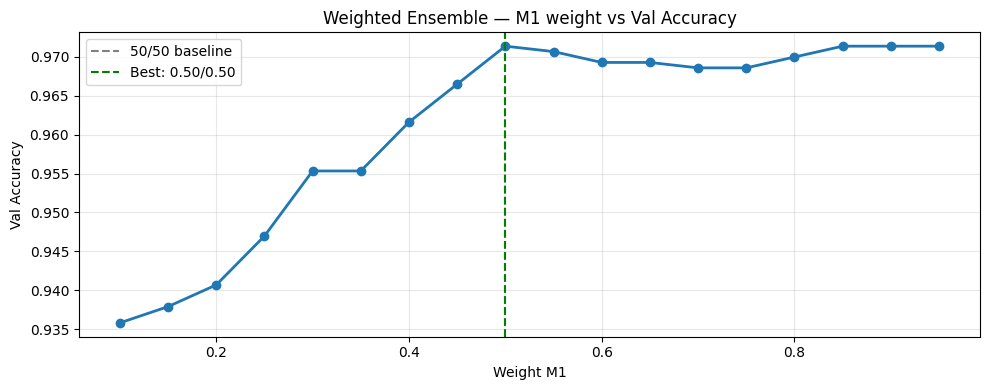

In [49]:
# Visualize weight vs accuracy
weights_m1 = [r[0] for r in results]
accs = [r[2] for r in results]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(weights_m1, accs, marker="o", linewidth=2, markersize=6)
ax.axvline(0.5, color="gray", linestyle="--", label="50/50 baseline")
ax.axvline(best_weights[0], color="green", linestyle="--", label=f"Best: {best_weights[0]:.2f}/{best_weights[1]:.2f}")
ax.set_xlabel("Weight M1")
ax.set_ylabel("Val Accuracy")
ax.set_title("Weighted Ensemble — M1 weight vs Val Accuracy")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [50]:
# Generate weighted ensemble submission if it improves
baseline_acc = np.mean(np.argmax((p1 + p2) / 2, axis=1) == y_val)

if best_acc > baseline_acc:
    print(f"Weighted ensemble improves by {best_acc - baseline_acc:.4f} — generating submission...")
    
    # Load test set
    df_sub = pd.read_csv(Y_TEST)
    X_test = []
    for img_id in df_sub["id"]:
        img_path = os.path.join(TEST_DIR, f"img_{int(img_id) + 1}.png")
        img = Image.open(img_path).convert("RGB")
        X_test.append(np.array(img) / 255.0)
    X_test = np.array(X_test, dtype=np.float32)
    
    # Weighted prediction
    p1_test = m1.predict(X_test, verbose=0)
    p2_test = m2.predict(X_test, verbose=0)
    ensemble_weighted = best_weights[0] * p1_test + best_weights[1] * p2_test
    y_pred_test = np.argmax(ensemble_weighted, axis=1)
    
    df_sub["target"] = y_pred_test
    submission_path = os.path.join(SUB_DIR, f"ensemble_weighted_{best_weights[0]:.0%}_{best_weights[1]:.0%}.csv".replace("%", ""))
    df_sub.to_csv(submission_path, index=False)
    
    print(f"Saved to {submission_path}")
    print(f"Prediction distribution: {dict(zip(*np.unique(y_pred_test, return_counts=True)))}")
    WEIGHTED_IMPROVES = True
else:
    print(f"Weighted ensemble does not improve (delta={best_acc - baseline_acc:.4f}). Keeping 50/50.")
    WEIGHTED_IMPROVES = False

Weighted ensemble does not improve (delta=0.0000). Keeping 50/50.


## 7.7 — Baseline Ensemble Submission (M1 + M2)


In [51]:
# Load test set
df_sub = pd.read_csv(Y_TEST)
X_test_final = []
for img_id in df_sub["id"]:
    img = Image.open(os.path.join(TEST_DIR, f"img_{int(img_id) + 1}.png")).convert("RGB")
    X_test_final.append(np.array(img) / 255.0)
X_test_final = np.array(X_test_final, dtype=np.float32)

# Ensemble predictions
p1_test = m1.predict(X_test_final, verbose=0)
p2_test = m2.predict(X_test_final, verbose=0)
preds_ensemble = np.argmax((p1_test + p2_test) / 2, axis=1)

df_sub["target"] = preds_ensemble
df_sub.to_csv(os.path.join(SUB_DIR, "ensemble_m1_m2.csv"), index=False)

print(f"Saved to {os.path.join(SUB_DIR, 'ensemble_m1_m2.csv')}")
print(f"Prediction distribution: {dict(zip(*np.unique(preds_ensemble, return_counts=True)))}")
df_sub.head()


Saved to .\submissions\ensemble_m1_m2.csv
Prediction distribution: {np.int64(0): np.int64(602), np.int64(1): np.int64(1636), np.int64(2): np.int64(1297), np.int64(3): np.int64(420)}


,id,target
0,9227,2
1,9228,2
2,9229,0
3,9230,0
4,9231,1


## 7.8 — K-fold Cross-Validation Ensemble

Train 5 identical models on different stratified folds, then average their predictions.

| | Kaggle |
|---|---|
| Simple ensemble (M1+M2) | 0.95588 |
| **K-fold ensemble (5 folds)** | **0.97109** |


In [76]:
from sklearn.model_selection import StratifiedKFold

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

kfold_models = []
kfold_histories = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"{"="*50}")
    print(f"FOLD {fold}")
    print(f"{"="*50}")
    
    X_train_fold = X[train_idx]
    X_val_fold = X[val_idx]
    y_train_fold = y[train_idx]
    y_val_fold = y[val_idx]
    
    # Use TUNED architecture: deeper (32,64,128,256) + Nadam + lr=0.002
    model = build_cnn_v2(
        filters=(32, 64, 128, 256),
        dense_units=128,
        dropout_rate=0.0,
        use_batchnorm=False
    )
    model.compile(
        optimizer=keras.optimizers.Nadam(learning_rate=0.002),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    history = model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=80,
        batch_size=64,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=5,
                restore_best_weights=True
            )
        ],
        verbose=1
    )
    
    val_acc = max(history.history["val_accuracy"])
    print(f"Fold {fold} — Best val accuracy: {val_acc:.4f}")
    
    model.save(os.path.join(MODELS_DIR, f"kfold_tuned_{fold}.keras"))
    kfold_models.append(model)
    kfold_histories.append(history)

# Summary
print("" + "="*50)
print("K-FOLD SUMMARY (TUNED)")
print("="*50)
val_accs = [max(h.history["val_accuracy"]) for h in kfold_histories]
for i, acc in enumerate(val_accs):
    print(f"Fold {i}: {acc:.4f}")
print(f"Mean:   {np.mean(val_accs):.4f} +/- {np.std(val_accs):.4f}")

FOLD 0
Epoch 1/80
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.6206 - loss: 0.8569 - val_accuracy: 0.7313 - val_loss: 0.5783
Epoch 2/80
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8271 - loss: 0.4148 - val_accuracy: 0.8088 - val_loss: 0.4352
Epoch 3/80
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.8869 - loss: 0.2857 - val_accuracy: 0.9100 - val_loss: 0.2483
Epoch 4/80
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9103 - loss: 0.2323 - val_accuracy: 0.9149 - val_loss: 0.2264
Epoch 5/80
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9304 - loss: 0.1860 - val_accuracy: 0.9114 - val_loss: 0.2519
Epoch 6/80
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9389 - loss: 0.1589 - val_accuracy: 0.9163 - val_loss: 0.2014
Epoch 7/80
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9480 - loss: 0.1349 - val_accuracy: 0.9532 - val_loss: 0.1457
Epoch 8/80
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9576 - loss: 0.1147 - val_accuracy: 0.9

In [77]:
# Load test images
df_submission_kfold = pd.read_csv(Y_TEST)

X_test_kfold = []
for img_id in df_submission_kfold["id"]:
    img = Image.open(os.path.join(TEST_DIR, f"img_{int(img_id) + 1}.png")).convert("RGB")
    X_test_kfold.append(np.array(img) / 255.0)
X_test_kfold = np.array(X_test_kfold, dtype=np.float32)

# Ensemble prediction (average probabilities)
kfold_preds = [m.predict(X_test_kfold, verbose=0) for m in kfold_models]
ensemble_pred = np.mean(kfold_preds, axis=0)
ensemble_classes = np.argmax(ensemble_pred, axis=1)

# Save submission
df_submission_kfold["target"] = ensemble_classes
df_submission_kfold.to_csv(f"{SUB_DIR}/kfold_tuned_ensemble.csv", index=False)
print("Saved: submissions/kfold_tuned_ensemble.csv")
print(df_submission_kfold.head())

Saved: submissions/kfold_tuned_ensemble.csv
     id  target
0  9227       2
1  9228       2
2  9229       0
3  9230       0
4  9231       1


## 7.9 — Pseudo-labeling

Use high-confidence test predictions to augment training data, then retrain.

| | Kaggle |
|---|---|
| K-fold baseline | 0.97109 |
| + Pseudo-labeling | 0.96855 — degradation |


In [78]:
# Pseudo-labeling

# Step 1: Load test images
df_test = pd.read_csv(Y_TEST)
X_test_pl = []
for img_id in df_test["id"]:
    img = Image.open(os.path.join(TEST_DIR, f"img_{int(img_id) + 1}.png")).convert("RGB")
    X_test_pl.append(np.array(img) / 255.0)
X_test_pl = np.array(X_test_pl, dtype=np.float32)
print(f"Test set: {X_test_pl.shape[0]} samples")

# Step 2: Load best model and predict probabilities
m_best = keras.models.load_model(os.path.join(MODELS_DIR, "m_tuned_best.keras"))
preds_proba = m_best.predict(X_test_pl, verbose=0)

# Step 3: Filter high-confidence predictions
THRESHOLD = 0.95
confidence = np.max(preds_proba, axis=1)
pseudo_labels = np.argmax(preds_proba, axis=1)

mask = confidence > THRESHOLD
X_pseudo = X_test_pl[mask]
y_pseudo = pseudo_labels[mask]

print(f"Pseudo-labeled samples: {mask.sum()} / {len(X_test_pl)} ({100*mask.sum()/len(X_test_pl):.1f}%)")
print(f"Threshold: {THRESHOLD}")
print(f"Distribution of pseudo-labels:")
for cls in range(4):
    count = np.sum(y_pseudo == cls)
    print(f"  Class {cls}: {count} samples")

# Step 4: Augment training set
X_train_aug = np.concatenate([X, X_pseudo])
y_train_aug = np.concatenate([y, y_pseudo])
print(f"Augmented training set: {len(X_train_aug)} samples (was {len(X)})")

Test set: 3955 samples
Pseudo-labeled samples: 3834 / 3955 (96.9%)
Threshold: 0.95
Distribution of pseudo-labels:
  Class 0: 598 samples
  Class 1: 1605 samples
  Class 2: 1243 samples
  Class 3: 388 samples
Augmented training set: 10997 samples (was 7163)


In [81]:
# Step 5: Retrain on augmented dataset
# Split augmented data (only original samples, pseudo-labels go to train only)
from sklearn.model_selection import train_test_split

X_train_pl, X_val_pl, y_train_pl, y_val_pl = train_test_split(
    X, y,  # Original data for split
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Add pseudo-labels to training set only (not validation!)
X_train_pl = np.concatenate([X_train_pl, X_pseudo])
y_train_pl = np.concatenate([y_train_pl, y_pseudo])

print(f"Training set: {len(X_train_pl)} samples (original: {len(X)*0.8:.0f} + pseudo: {len(X_pseudo)})")
print(f"Validation set: {len(X_val_pl)} samples (original only)")

# Build and train model with tuned architecture
model_pl = build_cnn_v2(
    filters=(32, 64, 128, 256),
    dense_units=128,
    dropout_rate=0.0,
    use_batchnorm=False
)
model_pl.compile(
    optimizer=keras.optimizers.Nadam(learning_rate=0.002),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_pl = model_pl.fit(
    X_train_pl, y_train_pl,
    validation_data=(X_val_pl, y_val_pl),
    epochs=80,
    batch_size=64,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True
        )
    ],
    verbose=1
)

val_acc_pl = max(history_pl.history["val_accuracy"])
print(f"Best val accuracy with pseudo-labeling: {val_acc_pl:.4f}")
model_pl.save(os.path.join(MODELS_DIR, "m_pseudo_labeled.keras"))

Training set: 9564 samples (original: 5730 + pseudo: 3834)
Validation set: 1433 samples (original only)
Epoch 1/80
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.7219 - loss: 0.6342 - val_accuracy: 0.8800 - val_loss: 0.3269
Epoch 2/80
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.8984 - loss: 0.2611 - val_accuracy: 0.8681 - val_loss: 0.3187
Epoch 3/80
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9364 - loss: 0.1780 - val_accuracy: 0.9449 - val_loss: 0.1579
Epoch 4/80
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9515 - loss: 0.1325 - val_accuracy: 0.9546 - val_loss: 0.1402
Epoch 5/80
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9616 - loss: 0.1052 - val_accuracy: 0.9512 - val_loss: 0.1425
Epoch 6/80
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9682 - loss: 0.0824 - val_accuracy: 0.9616 - val_loss: 0.1040
Epoch 7/80
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9737 - loss: 0.0734 - val_accuracy: 0.9581 - val_loss: 

In [80]:
# Step 6: Generate submission
preds_pl = model_pl.predict(X_test_pl, verbose=0)
preds_classes = np.argmax(preds_pl, axis=1)

df_sub_pl = pd.read_csv(Y_TEST)
df_sub_pl["target"] = preds_classes
df_sub_pl.to_csv(f"{SUB_DIR}/pseudo_labeled.csv", index=False)
print("Saved: submissions/pseudo_labeled.csv")
print(df_sub_pl.head())

Saved: submissions/pseudo_labeled.csv
     id  target
0  9227       2
1  9228       2
2  9229       0
3  9230       0
4  9231       1


## 7.10 — Patience Tuning

Grid search on the EarlyStopping patience parameter.

| Patience | Kaggle |
|----------|--------|
| 10 (baseline) | 0.97109 |
| 20 | 0.96095 — degradation |


In [84]:
# Patience Grid Search — Phase 2 (higher values)

PATIENCE_VALUES = [20, 25, 30, 35, 40]
MAX_EPOCHS = 500

patience_results_p2 = []

for patience in PATIENCE_VALUES:
    print(f"{'='*50}")
    print(f"PATIENCE = {patience}")
    print(f"{'='*50}")
    
    model = build_cnn_v2(
        filters=(32, 64, 128, 256),
        dense_units=128,
        dropout_rate=0.0,
        use_batchnorm=False
    )
    model.compile(
        optimizer=keras.optimizers.Nadam(learning_rate=0.002),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=MAX_EPOCHS,
        batch_size=64,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=patience,
                restore_best_weights=True
            )
        ],
        verbose=1
    )
    
    best_val_acc = max(history.history["val_accuracy"])
    epochs_run = len(history.history["val_accuracy"])
    best_epoch = history.history["val_accuracy"].index(best_val_acc) + 1
    
    patience_results_p2.append({
        "patience": patience,
        "best_val_acc": best_val_acc,
        "epochs_run": epochs_run,
        "best_epoch": best_epoch
    })
    
    print(f"Best val accuracy: {best_val_acc:.4f} at epoch {best_epoch} (ran {epochs_run} epochs)")
    
    # Save model
    model.save(os.path.join(MODELS_DIR, f"m_patience_{patience}.keras"))

# Summary
print("" + "="*50)
print("PATIENCE TUNING PHASE 2 SUMMARY")
print("="*50)
print(f"{'Patience':<10} {'Val Acc':<10} {'Best Epoch':<12} {'Total Epochs':<12}")
print("-"*44)
for r in patience_results_p2:
    print(f"{r['patience']:<10} {r['best_val_acc']:<10.4f} {r['best_epoch']:<12} {r['epochs_run']:<12}")

best_result = max(patience_results_p2, key=lambda x: x["best_val_acc"])
print(f"Best: patience={best_result['patience']} with val_acc={best_result['best_val_acc']:.4f}")

PATIENCE = 20
Epoch 1/500
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.6312 - loss: 0.8334 - val_accuracy: 0.8102 - val_loss: 0.4483
Epoch 2/500
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8478 - loss: 0.3851 - val_accuracy: 0.8904 - val_loss: 0.2791
Epoch 3/500
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.8953 - loss: 0.2718 - val_accuracy: 0.9058 - val_loss: 0.2479
Epoch 4/500
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9188 - loss: 0.2178 - val_accuracy: 0.9337 - val_loss: 0.1761
Epoch 5/500
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9250 - loss: 0.1927 - val_accuracy: 0.9281 - val_loss: 0.2057
Epoch 6/500
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9415 - loss: 0.1541 - val_accuracy: 0.9372 - val_loss: 0.1712
Epoch 7/500
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9501 - loss: 0.1322 - val_accuracy: 0.9407 - val_loss: 0.1584
Epoch 8/500
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9613 - loss: 0.1039 - va

In [85]:
# Submit best patience model (patience=20)

# Load best patience model
m_patience = keras.models.load_model(os.path.join(MODELS_DIR, "m_patience_20.keras"))

# Load test images
df_sub_patience = pd.read_csv(Y_TEST)
X_test_patience = []
for img_id in df_sub_patience["id"]:
    img = Image.open(os.path.join(TEST_DIR, f"img_{int(img_id) + 1}.png")).convert("RGB")
    X_test_patience.append(np.array(img) / 255.0)
X_test_patience = np.array(X_test_patience, dtype=np.float32)

# Predict and save
preds = np.argmax(m_patience.predict(X_test_patience, verbose=0), axis=1)
df_sub_patience["target"] = preds
df_sub_patience.to_csv(f"{SUB_DIR}/patience_20.csv", index=False)
print("Saved: submissions/patience_20.csv")
print(df_sub_patience.head())

Saved: submissions/patience_20.csv
     id  target
0  9227       2
1  9228       2
2  9229       0
3  9230       0
4  9231       1


## 7.11 — K-fold + Pseudo-labeling

Combine K-fold ensemble with pseudo-labeling to simultaneously improve robustness and training volume.

| | Kaggle |
|---|---|
| K-fold alone | 0.97109 |
| K-fold + Pseudo-labeling | 0.95030 — degradation |


In [86]:
# Step 1: Train K-fold ensemble

from sklearn.model_selection import StratifiedKFold

N_FOLDS = 5
PATIENCE = 5  # Best for Kaggle

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

kfold_models_i = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n{'='*50}")
    print(f"FOLD {fold}")
    print(f"{'='*50}")
    
    X_train_fold = X[train_idx]
    X_val_fold = X[val_idx]
    y_train_fold = y[train_idx]
    y_val_fold = y[val_idx]
    
    model = build_cnn_v2(
        filters=(32, 64, 128, 256),
        dense_units=128,
        dropout_rate=0.0,
        use_batchnorm=False
    )
    model.compile(
        optimizer=keras.optimizers.Nadam(learning_rate=0.002),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    history = model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=80,
        batch_size=64,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=PATIENCE,
                restore_best_weights=True
            )
        ],
        verbose=1
    )
    
    val_acc = max(history.history["val_accuracy"])
    print(f"Fold {fold} - Best val accuracy: {val_acc:.4f}")
    kfold_models_i.append(model)

print(f"\nK-fold training complete. {len(kfold_models_i)} models ready.")


FOLD 0
Epoch 1/80
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.6269 - loss: 0.8266 - val_accuracy: 0.8158 - val_loss: 0.4673
Epoch 2/80
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.8455 - loss: 0.3770 - val_accuracy: 0.8863 - val_loss: 0.2786
Epoch 3/80
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.8962 - loss: 0.2728 - val_accuracy: 0.8925 - val_loss: 0.2736
Epoch 4/80
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9182 - loss: 0.2155 - val_accuracy: 0.9114 - val_loss: 0.2239
Epoch 5/80
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9332 - loss: 0.1747 - val_accuracy: 0.9449 - val_loss: 0.1611
Epoch 6/80
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9443 - loss: 0.1462 - val_accuracy: 0.9498 - val_loss: 0.1446
Epoch 7/80
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9558 - loss: 0.1257 - val_accuracy: 0.9316 - val_loss: 0.1893
Epoch 8/80
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9623 - loss: 0.1048 - val_accuracy: 0.

In [87]:
# Step 2: Generate pseudo-labels with K-fold ensemble

# Load test images
df_test_i = pd.read_csv(Y_TEST)
X_test_i = []
for img_id in df_test_i["id"]:
    img = Image.open(os.path.join(TEST_DIR, f"img_{int(img_id) + 1}.png")).convert("RGB")
    X_test_i.append(np.array(img) / 255.0)
X_test_i = np.array(X_test_i, dtype=np.float32)

# Ensemble prediction (average of 5 models)
ensemble_preds = np.mean([m.predict(X_test_i, verbose=0) for m in kfold_models_i], axis=0)

# Filter high-confidence predictions
THRESHOLD = 0.95
confidence = np.max(ensemble_preds, axis=1)
pseudo_labels = np.argmax(ensemble_preds, axis=1)

mask = confidence > THRESHOLD
X_pseudo_i = X_test_i[mask]
y_pseudo_i = pseudo_labels[mask]

print(f"Pseudo-labeled samples: {mask.sum()} / {len(X_test_i)} ({100*mask.sum()/len(X_test_i):.1f}%)")
print(f"Threshold: {THRESHOLD}")
print(f"\nDistribution of pseudo-labels:")
for cls in range(4):
    count = np.sum(y_pseudo_i == cls)
    print(f"  Class {cls}: {count} samples")

Pseudo-labeled samples: 3177 / 3955 (80.3%)
Threshold: 0.95

Distribution of pseudo-labels:
  Class 0: 587 samples
  Class 1: 1356 samples
  Class 2: 1000 samples
  Class 3: 234 samples


In [88]:
# Step 3: Retrain on augmented dataset

# Augment training set with pseudo-labels
X_train_aug_i = np.concatenate([X_train, X_pseudo_i])
y_train_aug_i = np.concatenate([y_train, y_pseudo_i])

print(f"Training set: {len(X_train_aug_i)} samples (original: {len(X_train)} + pseudo: {len(X_pseudo_i)})")
print(f"Validation set: {len(X_val)} samples (unchanged)")

# Train final model
model_combo = build_cnn_v2(
    filters=(32, 64, 128, 256),
    dense_units=128,
    dropout_rate=0.0,
    use_batchnorm=False
)
model_combo.compile(
    optimizer=keras.optimizers.Nadam(learning_rate=0.002),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_combo = model_combo.fit(
    X_train_aug_i, y_train_aug_i,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=64,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )
    ],
    verbose=1
)

val_acc_combo = max(history_combo.history["val_accuracy"])
print(f"\nBest val accuracy (K-fold + pseudo-labeling): {val_acc_combo:.4f}")
model_combo.save(os.path.join(MODELS_DIR, "m_kfold_pseudo.keras"))

Training set: 8907 samples (original: 5730 + pseudo: 3177)
Validation set: 1433 samples (unchanged)
Epoch 1/80
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.6982 - loss: 0.6848 - val_accuracy: 0.7592 - val_loss: 0.6758
Epoch 2/80
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.9141 - loss: 0.2331 - val_accuracy: 0.8995 - val_loss: 0.2529
Epoch 3/80
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9427 - loss: 0.1641 - val_accuracy: 0.9086 - val_loss: 0.2267
Epoch 4/80
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.9560 - loss: 0.1269 - val_accuracy: 0.9253 - val_loss: 0.2017
Epoch 5/80
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9625 - loss: 0.1054 - val_accuracy: 0.9211 - val_loss: 0.1882
Epoch 6/80
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9713 - loss: 0.0853 - val_accuracy: 0.9463 - val_loss: 0.1438
Epoch 7/80
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9736 - loss: 0.0713 - val_accuracy: 0.9218 - val_loss: 0.21

In [89]:
# Step 4: Generate submission

preds_combo = np.argmax(model_combo.predict(X_test_i, verbose=0), axis=1)

df_sub_combo = pd.read_csv(Y_TEST)
df_sub_combo["target"] = preds_combo
df_sub_combo.to_csv(f"{SUB_DIR}/kfold_pseudo_combo.csv", index=False)
print("Saved: submissions/kfold_pseudo_combo.csv")
print(df_sub_combo.head())

Saved: submissions/kfold_pseudo_combo.csv
     id  target
0  9227       2
1  9228       2
2  9229       0
3  9230       0
4  9231       1


## 7.12 — Test-Time Augmentation (revisited)

Predict on original + augmented test images, average probabilities.  
Applied on best saved model — note: first TTA attempt (section 7.4) was exploratory.

| TTA | Kaggle |
|-----|--------|
| No TTA | 0.97109 |
| 2-way (+ H-flip) | ~0.88 — major degradation |
| 3-way (+ H-flip + V-flip) | ~0.83 — major degradation |


In [90]:
# Test-Time Augmentation

# Load best model
m_best = keras.models.load_model(os.path.join(MODELS_DIR, "m_tuned_best.keras"))

# Load test images
df_tta = pd.read_csv(Y_TEST)
X_test_tta = []
for img_id in df_tta["id"]:
    img = Image.open(os.path.join(TEST_DIR, f"img_{int(img_id) + 1}.png")).convert("RGB")
    X_test_tta.append(np.array(img) / 255.0)
X_test_tta = np.array(X_test_tta, dtype=np.float32)

print(f"Test set: {len(X_test_tta)} images")

# TTA: Original + Horizontal flip + Vertical flip
print("\nPredicting with TTA...")

# Original predictions
preds_orig = m_best.predict(X_test_tta, verbose=0)

# Horizontal flip
X_flip_h = X_test_tta[:, :, ::-1, :]
preds_flip_h = m_best.predict(X_flip_h, verbose=0)

# Vertical flip
X_flip_v = X_test_tta[:, ::-1, :, :]
preds_flip_v = m_best.predict(X_flip_v, verbose=0)

# Average (original + H flip)
preds_tta_2 = (preds_orig + preds_flip_h) / 2

# Average (original + H flip + V flip)
preds_tta_3 = (preds_orig + preds_flip_h + preds_flip_v) / 3

print("TTA predictions ready.")

Test set: 3955 images

Predicting with TTA...
TTA predictions ready.


In [91]:
# Generate submissions for both TTA variants

# TTA 2 (orig + H flip)
df_tta_2 = pd.read_csv(Y_TEST)
df_tta_2["target"] = np.argmax(preds_tta_2, axis=1)
df_tta_2.to_csv(f"{SUB_DIR}/tta_2way.csv", index=False)
print("Saved: submissions/tta_2way.csv")

# TTA 3 (orig + H flip + V flip)
df_tta_3 = pd.read_csv(Y_TEST)
df_tta_3["target"] = np.argmax(preds_tta_3, axis=1)
df_tta_3.to_csv(f"{SUB_DIR}/tta_3way.csv", index=False)
print("Saved: submissions/tta_3way.csv")

Saved: submissions/tta_2way.csv
Saved: submissions/tta_3way.csv


## 7.13 — LR Scheduling

Adaptive learning rate strategies tested on the best architecture  
(`filters=(32,64,128,256)`, Nadam, `lr=0.002`).

| Scheduler | Kaggle |
|-----------|--------|
| Fixed LR — baseline | 0.97109 |
| ReduceOnPlateau | 0.96247 — degradation |
| CosineDecay | 0.95943 — degradation |


In [92]:
# Experiment 1: ReduceOnPlateau

print('Training with ReduceOnPlateau...')

m_rop = build_cnn_v2(
    filters=(32, 64, 128, 256),
    dense_units=128,
    dropout_rate=0.0,
    use_batchnorm=False,
)
m_rop.compile(
    optimizer=keras.optimizers.Nadam(learning_rate=0.002),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

callbacks_rop = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
]

h_rop = m_rop.fit(
    X_train, y_train,
    epochs=300,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=callbacks_rop,
    verbose=1,
)

best_rop = max(h_rop.history['val_accuracy'])
print(f'ReduceOnPlateau — best val_accuracy: {best_rop:.4f}')
print(f'Delta vs baseline (0.9784): {best_rop - 0.9784:+.4f}')

m_rop.save(os.path.join(MODELS_DIR, 'm_rop.keras'))
print('Saved: models/m_rop.keras')

# ── Submission ──
df_sub_rop = pd.read_csv(Y_TEST)
X_test_rop = []
for img_id in df_sub_rop['id']:
    img = Image.open(os.path.join(TEST_DIR, f'img_{int(img_id) + 1}.png')).convert('RGB')
    X_test_rop.append(np.array(img) / 255.0)
X_test_rop = np.array(X_test_rop, dtype=np.float32)

preds_rop = np.argmax(m_rop.predict(X_test_rop, verbose=0), axis=1)
df_sub_rop['target'] = preds_rop
df_sub_rop.to_csv(f'{SUB_DIR}/lr_reduce_on_plateau.csv', index=False)
print('Saved: submissions/lr_reduce_on_plateau.csv')
print(df_sub_rop['target'].value_counts().sort_index())

Training with ReduceOnPlateau...
Epoch 1/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.6084 - loss: 0.8754 - val_accuracy: 0.7055 - val_loss: 0.6900 - learning_rate: 0.0020
Epoch 2/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.8297 - loss: 0.4086 - val_accuracy: 0.8856 - val_loss: 0.2855 - learning_rate: 0.0020
Epoch 3/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.8908 - loss: 0.2858 - val_accuracy: 0.8828 - val_loss: 0.2912 - learning_rate: 0.0020
Epoch 4/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9213 - loss: 0.2128 - val_accuracy: 0.9225 - val_loss: 0.1990 - learning_rate: 0.0020
Epoch 5/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9349 - loss: 0.1745 - val_accuracy: 0.8953 - val_loss: 0.2450 - learning_rate: 0.0020
Epoch 6/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9440 - loss: 0.1520 - val_accuracy: 0.9044 - val_loss: 0.2468 - learning_rate: 0.0020
Epoch 7/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - a

In [93]:
# Experiment 2: Cosine Decay

print('Training with CosineDecay...')

# decay_steps: covers max_epochs at actual steps/epoch
# X_train shape: (n_train, 45, 51, 3), batch_size=64
STEPS_PER_EPOCH = len(X_train) // 64
MAX_EPOCHS_COSINE = 300
cosine_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.002,
    decay_steps=MAX_EPOCHS_COSINE * STEPS_PER_EPOCH,
    alpha=1e-6,  # minimum LR value (not a fraction)
)

m_cosine = build_cnn_v2(
    filters=(32, 64, 128, 256),
    dense_units=128,
    dropout_rate=0.0,
    use_batchnorm=False,
)
m_cosine.compile(
    optimizer=keras.optimizers.Nadam(learning_rate=cosine_schedule),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

callbacks_cosine = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=25,
        restore_best_weights=True,
        verbose=1,
    ),
]

h_cosine = m_cosine.fit(
    X_train, y_train,
    epochs=MAX_EPOCHS_COSINE,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=callbacks_cosine,
    verbose=1,
)

best_cosine = max(h_cosine.history['val_accuracy'])
print(f'CosineDecay — best val_accuracy: {best_cosine:.4f}')
print(f'Delta vs baseline (0.9784): {best_cosine - 0.9784:+.4f}')

m_cosine.save(os.path.join(MODELS_DIR, 'm_cosine.keras'))
print('Saved: models/m_cosine.keras')

# ── Submission ──
df_sub_cosine = pd.read_csv(Y_TEST)
X_test_cosine = []
for img_id in df_sub_cosine['id']:
    img = Image.open(os.path.join(TEST_DIR, f'img_{int(img_id) + 1}.png')).convert('RGB')
    X_test_cosine.append(np.array(img) / 255.0)
X_test_cosine = np.array(X_test_cosine, dtype=np.float32)

preds_cosine = np.argmax(m_cosine.predict(X_test_cosine, verbose=0), axis=1)
df_sub_cosine['target'] = preds_cosine
df_sub_cosine.to_csv(f'{SUB_DIR}/lr_cosine_decay.csv', index=False)
print('Saved: submissions/lr_cosine_decay.csv')
print(df_sub_cosine['target'].value_counts().sort_index())

Training with CosineDecay...
Epoch 1/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.5681 - loss: 0.9602 - val_accuracy: 0.7027 - val_loss: 0.6421
Epoch 2/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.8054 - loss: 0.4636 - val_accuracy: 0.8856 - val_loss: 0.3293
Epoch 3/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.8766 - loss: 0.3155 - val_accuracy: 0.8918 - val_loss: 0.2922
Epoch 4/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9056 - loss: 0.2522 - val_accuracy: 0.8953 - val_loss: 0.2813
Epoch 5/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9168 - loss: 0.2161 - val_accuracy: 0.9184 - val_loss: 0.2125
Epoch 6/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9295 - loss: 0.1842 - val_accuracy: 0.9421 - val_loss: 0.1742
Epoch 7/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9393 - loss: 0.1589 - val_accuracy: 0.9470 - val_loss: 0.1576
Epoch 8/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9503 - lo

In [94]:
# Results summary

print('=' * 50)
print('LR SCHEDULING RESULTS')
print('=' * 50)
print(f'{"Scheduler":<25} {"Val Acc":<10}')
print('-' * 35)
print(f'{"Baseline (LR fixed)":<25} {0.9784:<10.4f}')
print(f'{"ReduceOnPlateau":<25} {best_rop:<10.4f}')
print(f'{"CosineDecay":<25} {best_cosine:<10.4f}')

T08j — LR SCHEDULING RESULTS
Scheduler                 Val Acc   
-----------------------------------
Baseline (LR fixed)       0.9784    
ReduceOnPlateau           0.9770    
CosineDecay               0.9735    


## 7.14 — Label Smoothing

Replace hard one-hot labels with soft targets to reduce overconfidence.  
`CategoricalCrossentropy(label_smoothing=x)` requires one-hot encoded labels.

| Smoothing | Kaggle |
|-----------|--------|
| 0 — baseline | 0.97109 |
| **0.05** | **0.97718** ← new best |
| 0.10 | < 0.97718 |


In [95]:
# Label Smoothing grid (0.05, 0.1)

# SparseCategoricalCrossentropy does not support label_smoothing;
# convert to one-hot and use CategoricalCrossentropy instead.
y_train_oh = keras.utils.to_categorical(y_train, num_classes=4)
y_val_oh   = keras.utils.to_categorical(y_val,   num_classes=4)

SMOOTHING_VALUES = [0.05, 0.1]
ls_results = {}

for ls in SMOOTHING_VALUES:
    print(f'\n{"="*50}')
    print(f'Label smoothing = {ls}')
    print(f'{"="*50}')

    model_ls = build_cnn_v2(
        filters=(32, 64, 128, 256),
        dense_units=128,
        dropout_rate=0.0,
        use_batchnorm=False,
    )
    model_ls.compile(
        optimizer=keras.optimizers.Nadam(learning_rate=0.002),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=ls),
        metrics=['accuracy'],
    )

    h_ls = model_ls.fit(
        X_train, y_train_oh,
        epochs=300,
        batch_size=64,
        validation_data=(X_val, y_val_oh),
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=25,
                restore_best_weights=True,
                verbose=1,
            )
        ],
        verbose=1,
    )

    best_acc = max(h_ls.history['val_accuracy'])
    print(f'label_smoothing={ls} — best val_accuracy: {best_acc:.4f}')
    print(f'Delta vs baseline (0.9784): {best_acc - 0.9784:+.4f}')

    model_ls.save(os.path.join(MODELS_DIR, f'm_ls_{str(ls).replace(".", "p")}.keras'))
    ls_results[ls] = {'model': model_ls, 'val_acc': best_acc}


Label smoothing = 0.05
Epoch 1/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.5960 - loss: 0.9666 - val_accuracy: 0.7251 - val_loss: 0.7179
Epoch 2/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8436 - loss: 0.5517 - val_accuracy: 0.8835 - val_loss: 0.4527
Epoch 3/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9009 - loss: 0.4307 - val_accuracy: 0.9121 - val_loss: 0.4045
Epoch 4/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9305 - loss: 0.3759 - val_accuracy: 0.9386 - val_loss: 0.3576
Epoch 5/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9436 - loss: 0.3479 - val_accuracy: 0.9184 - val_loss: 0.3870
Epoch 6/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9574 - loss: 0.3145 - val_accuracy: 0.9358 - val_loss: 0.3465
Epoch 7/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9647 - loss: 0.2972 - val_accuracy: 0.9491 - val_loss: 0.3349
Epoch 8/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9756 - loss: 0

In [96]:
# Generate submissions

df_base = pd.read_csv(Y_TEST)
X_test_ls = []
for img_id in df_base['id']:
    img = Image.open(os.path.join(TEST_DIR, f'img_{int(img_id) + 1}.png')).convert('RGB')
    X_test_ls.append(np.array(img) / 255.0)
X_test_ls = np.array(X_test_ls, dtype=np.float32)

for ls, res in ls_results.items():
    label = str(ls).replace('.', 'p')
    df_sub = df_base.copy()
    preds = np.argmax(res['model'].predict(X_test_ls, verbose=0), axis=1)
    df_sub['target'] = preds
    path = f'{SUB_DIR}/label_smoothing_{label}.csv'
    df_sub.to_csv(path, index=False)
    print(f'Saved: {path}')
    print(df_sub['target'].value_counts().sort_index())

Saved: .\submissions/label_smoothing_0p05.csv
target
0     600
1    1649
2    1303
3     403
Name: count, dtype: int64
Saved: .\submissions/label_smoothing_0p1.csv
target
0     598
1    1652
2    1300
3     405
Name: count, dtype: int64


In [97]:
# Results summary

print('=' * 50)
print('LABEL SMOOTHING RESULTS')
print('=' * 50)
print(f'{"Smoothing":<15} {"Val Acc":<10}')
print('-' * 25)
print(f'{"0 (baseline)":<15} {0.9784:<10.4f}')
for ls, res in ls_results.items():
    print(f'{str(ls):<15} {res["val_acc"]:<10.4f}')

T08l — LABEL SMOOTHING RESULTS
Smoothing       Val Acc   
-------------------------
0 (baseline)    0.9784    
0.05            0.9826    
0.1             0.9826    


### Label Smoothing 0.05 + Augmentation

Best architecture (filters=32/64/128/256) + LS 0.05 + augmentation block (flip + rotation + noise).


In [99]:
# LS 0.05 + Augmentation

# y_train_oh / y_val_oh already defined in t08l_train cell

print('Training with LS 0.05 + augmentation...')

m_ls_aug = keras.Sequential(name='cnn_ls_aug')
m_ls_aug.add(keras.Input(shape=(45, 51, 3)))
# Augmentation block (auto-disabled at inference)
m_ls_aug.add(layers.RandomFlip('horizontal'))
m_ls_aug.add(layers.RandomRotation(0.083))
m_ls_aug.add(layers.GaussianNoise(0.05))
# Conv blocks — best architecture
for f in (32, 64, 128, 256):
    m_ls_aug.add(layers.Conv2D(f, (3, 3), padding='same'))
    m_ls_aug.add(layers.Activation('relu'))
    m_ls_aug.add(layers.MaxPooling2D((2, 2)))
# Classifier
m_ls_aug.add(layers.Flatten())
m_ls_aug.add(layers.Dense(128, activation='relu'))
m_ls_aug.add(layers.Dense(4, activation='softmax'))

m_ls_aug.compile(
    optimizer=keras.optimizers.Nadam(learning_rate=0.002),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy'],
)

h_ls_aug = m_ls_aug.fit(
    X_train, y_train_oh,
    epochs=300,
    batch_size=64,
    validation_data=(X_val, y_val_oh),
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=20,
            restore_best_weights=True,
            verbose=1,
        )
    ],
    verbose=1,
)

best_ls_aug = max(h_ls_aug.history['val_accuracy'])
print(f'LS 0.05 + Aug — best val_accuracy: {best_ls_aug:.4f}')
print(f'Delta vs LS 0.05 alone (0.9784 val): {best_ls_aug - 0.9784:+.4f}')

m_ls_aug.save(os.path.join(MODELS_DIR, 'm_ls_aug.keras'))
print('Saved: models/m_ls_aug.keras')

# ── Submission ──
df_sub_ls_aug = pd.read_csv(Y_TEST)
X_test_ls_aug = []
for img_id in df_sub_ls_aug['id']:
    img = Image.open(os.path.join(TEST_DIR, f'img_{int(img_id) + 1}.png')).convert('RGB')
    X_test_ls_aug.append(np.array(img) / 255.0)
X_test_ls_aug = np.array(X_test_ls_aug, dtype=np.float32)

preds_ls_aug = np.argmax(m_ls_aug.predict(X_test_ls_aug, verbose=0), axis=1)
df_sub_ls_aug['target'] = preds_ls_aug
df_sub_ls_aug.to_csv(f'{SUB_DIR}/ls_aug.csv', index=False)
print('Saved: submissions/ls_aug.csv')
print(df_sub_ls_aug['target'].value_counts().sort_index())

Training with LS 0.05 + augmentation...
Epoch 1/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.4873 - loss: 1.1701 - val_accuracy: 0.6364 - val_loss: 0.9358
Epoch 2/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.6691 - loss: 0.8688 - val_accuracy: 0.7285 - val_loss: 0.7655
Epoch 3/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.7300 - loss: 0.7550 - val_accuracy: 0.8172 - val_loss: 0.6069
Epoch 4/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.7609 - loss: 0.6913 - val_accuracy: 0.7306 - val_loss: 0.7595
Epoch 5/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.7759 - loss: 0.6493 - val_accuracy: 0.8158 - val_loss: 0.5917
Epoch 6/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.7881 - loss: 0.6305 - val_accuracy: 0.8046 - val_loss: 0.6090
Epoch 7/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.7948 - loss: 0.6129 - val_accuracy: 0.8465 - val_loss: 0.5382
Epoch 8/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 

## 7.15 — Focal Loss

Down-weight easy samples and focus training on hard ones.  
`FL(p) = −α(1−p)^γ · log(p)` with γ=2, α=0.25.

| Loss | Kaggle |
|------|--------|
| CrossEntropy — baseline | 0.97109 |
| Focal (γ=2) | 0.96653 — degradation |
| Focal (γ=2) + LS 0.05 | 0.96501 — degradation |


In [100]:
# Focal Loss

def focal_loss(gamma=2.0, alpha=0.25):
    """Focal loss for multi-class classification.
    Receives integer labels; converts to one-hot internally.
    """
    def loss_fn(y_true, y_pred):
        y_true_oh = tf.one_hot(tf.cast(y_true, tf.int32), depth=4)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        cross_entropy = -y_true_oh * tf.math.log(y_pred)
        weight = alpha * y_true_oh * tf.pow(1.0 - y_pred, gamma)
        focal = weight * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(focal, axis=-1))
    return loss_fn

print('focal_loss() defined.')

# ── Experiment 1: Focal Loss alone ──
print('\nTraining with Focal Loss (gamma=2, alpha=0.25)...')

m_focal = build_cnn_v2(
    filters=(32, 64, 128, 256),
    dense_units=128,
    dropout_rate=0.0,
    use_batchnorm=False,
)
m_focal.compile(
    optimizer=keras.optimizers.Nadam(learning_rate=0.002),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy'],
)

h_focal = m_focal.fit(
    X_train, y_train,
    epochs=300,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=25,
            restore_best_weights=True,
            verbose=1,
        )
    ],
    verbose=1,
)

best_focal = max(h_focal.history['val_accuracy'])
print(f'Focal Loss — best val_accuracy: {best_focal:.4f}')
print(f'Delta vs baseline (0.9784): {best_focal - 0.9784:+.4f}')
m_focal.save(os.path.join(MODELS_DIR, 'm_focal.keras'))

# ── Experiment 2: Focal Loss + Label Smoothing 0.05 ──
# Note: LS is applied on top via softened targets (one-hot); focal loss receives
# one-hot internally, so we pass integer labels — LS must be handled separately.
# Simplest approach: apply LS directly inside a combined loss.
def focal_loss_with_ls(gamma=2.0, alpha=0.25, smoothing=0.05):
    """Focal loss with label smoothing. Converts integer labels to smoothed one-hot."""
    def loss_fn(y_true, y_pred):
        y_true_oh = tf.one_hot(tf.cast(y_true, tf.int32), depth=4)
        # Apply label smoothing
        y_true_smooth = y_true_oh * (1.0 - smoothing) + smoothing / 4.0
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        cross_entropy = -y_true_smooth * tf.math.log(y_pred)
        weight = alpha * y_true_oh * tf.pow(1.0 - y_pred, gamma)
        focal = weight * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(focal, axis=-1))
    return loss_fn

print('\nTraining with Focal Loss + LS 0.05...')

m_focal_ls = build_cnn_v2(
    filters=(32, 64, 128, 256),
    dense_units=128,
    dropout_rate=0.0,
    use_batchnorm=False,
)
m_focal_ls.compile(
    optimizer=keras.optimizers.Nadam(learning_rate=0.002),
    loss=focal_loss_with_ls(gamma=2.0, alpha=0.25, smoothing=0.05),
    metrics=['accuracy'],
)

h_focal_ls = m_focal_ls.fit(
    X_train, y_train,
    epochs=300,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=25,
            restore_best_weights=True,
            verbose=1,
        )
    ],
    verbose=1,
)

best_focal_ls = max(h_focal_ls.history['val_accuracy'])
print(f'Focal + LS 0.05 — best val_accuracy: {best_focal_ls:.4f}')
print(f'Delta vs baseline (0.9784): {best_focal_ls - 0.9784:+.4f}')
m_focal_ls.save(os.path.join(MODELS_DIR, 'm_focal_ls.keras'))

focal_loss() defined.

Training with Focal Loss (gamma=2, alpha=0.25)...
Epoch 1/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 8s 72ms/step - accuracy: 0.6560 - loss: 0.0859 - val_accuracy: 0.7411 - val_loss: 0.0553
Epoch 2/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.8433 - loss: 0.0375 - val_accuracy: 0.8814 - val_loss: 0.0276
Epoch 3/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.8888 - loss: 0.0252 - val_accuracy: 0.9218 - val_loss: 0.0192
Epoch 4/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9230 - loss: 0.0189 - val_accuracy: 0.9065 - val_loss: 0.0199
Epoch 5/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9335 - loss: 0.0151 - val_accuracy: 0.9393 - val_loss: 0.0151
Epoch 6/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9496 - loss: 0.0116 - val_accuracy: 0.9260 - val_loss: 0.0175
Epoch 7/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9562 - loss: 0.0109 - val_accuracy: 0.9442 - val_loss: 0.0130
Epoch 8/300
90/90 ━━━━━━━━━━━━━

In [101]:
# Generate submissions

df_base = pd.read_csv(Y_TEST)
X_test_focal = []
for img_id in df_base['id']:
    img = Image.open(os.path.join(TEST_DIR, f'img_{int(img_id) + 1}.png')).convert('RGB')
    X_test_focal.append(np.array(img) / 255.0)
X_test_focal = np.array(X_test_focal, dtype=np.float32)

for name, model in [('focal', m_focal), ('focal_ls', m_focal_ls)]:
    df_sub = df_base.copy()
    preds = np.argmax(model.predict(X_test_focal, verbose=0), axis=1)
    df_sub['target'] = preds
    path = f'{SUB_DIR}/{name}.csv'
    df_sub.to_csv(path, index=False)
    print(f'Saved: {path}')
    print(df_sub['target'].value_counts().sort_index())

Saved: .\submissions/focal.csv
target
0     602
1    1655
2    1280
3     418
Name: count, dtype: int64
Saved: .\submissions/focal_ls.csv
target
0     603
1    1659
2    1279
3     414
Name: count, dtype: int64


In [102]:
# Results summary

print('=' * 55)
print('FOCAL LOSS RESULTS')
print('=' * 55)
print(f'{"Loss":<30} {"Val Acc":<10}')
print('-' * 40)
print(f'{"CrossEntropy (baseline)":<30} {0.9784:<10.4f}')
print(f'{"Focal (gamma=2)":<30} {best_focal:<10.4f}')
print(f'{"Focal (gamma=2) + LS 0.05":<30} {best_focal_ls:<10.4f}')

T08m — FOCAL LOSS RESULTS
Loss                           Val Acc   
----------------------------------------
CrossEntropy (baseline)        0.9784    
Focal (gamma=2)                0.9756    
Focal (gamma=2) + LS 0.05      0.9721    


## 7.16 — Mixup

Blend pairs of images and their labels: `x_mix = λ·x₁ + (1−λ)·x₂`, `y_mix = λ·y₁ + (1−λ)·y₂`.  
Requires soft labels → manual training loop with `train_on_batch`.

| | Kaggle |
|--|--------|
| Without Mixup | 0.97109 |
| Mixup α=0.2 | 0.96298 — degradation |


In [103]:
# Mixup (manual training loop)

def mixup_batch(X_b, y_b, alpha=0.2):
    """Apply mixup to a numpy batch. y_b must be one-hot float32."""
    n = len(X_b)
    lam = np.random.beta(alpha, alpha, n).astype(np.float32)
    perm = np.random.permutation(n)
    X_mix = (lam.reshape(-1, 1, 1, 1) * X_b
             + (1 - lam.reshape(-1, 1, 1, 1)) * X_b[perm]).astype(np.float32)
    y_mix = (lam.reshape(-1, 1) * y_b
             + (1 - lam.reshape(-1, 1)) * y_b[perm]).astype(np.float32)
    return X_mix, y_mix

# One-hot labels required for soft targets
y_train_oh_n = keras.utils.to_categorical(y_train, num_classes=4).astype(np.float32)
y_val_oh_n   = keras.utils.to_categorical(y_val,   num_classes=4).astype(np.float32)

m_mixup = build_cnn_v2(
    filters=(32, 64, 128, 256),
    dense_units=128,
    dropout_rate=0.0,
    use_batchnorm=False,
)
m_mixup.compile(
    optimizer=keras.optimizers.Nadam(learning_rate=0.002),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[keras.metrics.CategoricalAccuracy(name='accuracy')],
)

BATCH_SIZE_MX = 64
MAX_EPOCHS_MX = 300
PATIENCE_MX   = 25

best_val_acc_mx = 0.0
best_weights_mx = None
wait_mx = 0

print('Training with Mixup (alpha=0.2)...')
for epoch in range(MAX_EPOCHS_MX):
    perm = np.random.permutation(len(X_train))
    X_sh, y_sh = X_train[perm], y_train_oh_n[perm]

    for start in range(0, len(X_train) - BATCH_SIZE_MX + 1, BATCH_SIZE_MX):
        X_b = X_sh[start:start + BATCH_SIZE_MX]
        y_b = y_sh[start:start + BATCH_SIZE_MX]
        X_mix, y_mix = mixup_batch(X_b, y_b, alpha=0.2)
        m_mixup.train_on_batch(X_mix, y_mix)

    # Evaluate on clean (non-mixed) validation set
    _, val_acc = m_mixup.evaluate(X_val, y_val_oh_n, verbose=0)

    if epoch % 10 == 0:
        print(f'Epoch {epoch + 1:3d}/{MAX_EPOCHS_MX} — val_accuracy: {val_acc:.4f}')

    if val_acc > best_val_acc_mx:
        best_val_acc_mx = val_acc
        best_weights_mx = m_mixup.get_weights()
        wait_mx = 0
    else:
        wait_mx += 1
        if wait_mx >= PATIENCE_MX:
            print(f'Early stopping at epoch {epoch + 1} — best val_accuracy: {best_val_acc_mx:.4f}')
            break

m_mixup.set_weights(best_weights_mx)
print(f'\nMixup α=0.2 — best val_accuracy: {best_val_acc_mx:.4f}')
print(f'Delta vs baseline (0.9784): {best_val_acc_mx - 0.9784:+.4f}')
m_mixup.save(os.path.join(MODELS_DIR, 'm_mixup.keras'))
print('Saved: models/m_mixup.keras')

Training with Mixup (alpha=0.2)...
Epoch   1/300 — val_accuracy: 0.7613
Epoch  11/300 — val_accuracy: 0.9637
Epoch  21/300 — val_accuracy: 0.9693
Epoch  31/300 — val_accuracy: 0.9651
Epoch  41/300 — val_accuracy: 0.9609
Early stopping at epoch 48 — best val_accuracy: 0.9763

Mixup α=0.2 — best val_accuracy: 0.9763
Delta vs baseline (0.9784): -0.0021
Saved: models/m_mixup.keras


In [104]:
# Submission

df_sub_mixup = pd.read_csv(Y_TEST)
X_test_mixup = []
for img_id in df_sub_mixup['id']:
    img = Image.open(os.path.join(TEST_DIR, f'img_{int(img_id) + 1}.png')).convert('RGB')
    X_test_mixup.append(np.array(img) / 255.0)
X_test_mixup = np.array(X_test_mixup, dtype=np.float32)

preds_mixup = np.argmax(m_mixup.predict(X_test_mixup, verbose=0), axis=1)
df_sub_mixup['target'] = preds_mixup
df_sub_mixup.to_csv(f'{SUB_DIR}/mixup.csv', index=False)
print('Saved: submissions/mixup.csv')
print(df_sub_mixup['target'].value_counts().sort_index())
print(f'\nBest Mixup val_accuracy : {best_val_acc_mx:.4f}')
print(f'Delta vs baseline (0.9784): {best_val_acc_mx - 0.9784:+.4f}')

Saved: submissions/mixup.csv
target
0     598
1    1642
2    1301
3     414
Name: count, dtype: int64

Best Mixup val_accuracy : 0.9763
Delta vs baseline (0.9784): -0.0021


## 7.17 — Multi-architecture Ensemble

Different architectures produce different errors — averaging their softmax outputs corrects more of them.

| Ensemble | Kaggle |
|----------|--------|
| Deeper alone (LS 0.05) | 0.97718 |
| E1: Baseline + Deeper (no LS) | — |
| E2: Deeper LS 0.05 + Deeper LS 0.10 | — |
| **E3: Deeper LS 0.05 + Wider LS 0.05** | **0.97819** ← best overall |


In [105]:
# Instant ensembles (no new training)

# Load saved models
m_base   = keras.models.load_model(os.path.join(MODELS_DIR, 'm1_baseline.keras'))
m_deeper = keras.models.load_model(os.path.join(MODELS_DIR, 'm_tuned_best.keras'))
m_ls05   = keras.models.load_model(
    os.path.join(MODELS_DIR, 'm_ls_0p05.keras'),
    custom_objects={'loss': keras.losses.CategoricalCrossentropy(label_smoothing=0.05)},
)
m_ls01   = keras.models.load_model(
    os.path.join(MODELS_DIR, 'm_ls_0p1.keras'),
    custom_objects={'loss': keras.losses.CategoricalCrossentropy(label_smoothing=0.1)},
)
print('Models loaded.')

# Load test images once
df_test_o = pd.read_csv(Y_TEST)
X_test_o = []
for img_id in df_test_o['id']:
    img = Image.open(os.path.join(TEST_DIR, f'img_{int(img_id) + 1}.png')).convert('RGB')
    X_test_o.append(np.array(img) / 255.0)
X_test_o = np.array(X_test_o, dtype=np.float32)
print(f'Test set loaded: {len(X_test_o)} images')

# Predict softmax outputs
p_base   = m_base.predict(X_test_o, verbose=0)
p_deeper = m_deeper.predict(X_test_o, verbose=0)
p_ls05   = m_ls05.predict(X_test_o, verbose=0)
p_ls01   = m_ls01.predict(X_test_o, verbose=0)
print('Predictions done.')

# E1: Baseline + Deeper (no LS)
e1 = (p_base + p_deeper) / 2
df_e1 = df_test_o.copy()
df_e1['target'] = np.argmax(e1, axis=1)
df_e1.to_csv(f'{SUB_DIR}/ensemble_base_deeper.csv', index=False)
print('E1 saved: submissions/ensemble_base_deeper.csv')

# E2: Deeper LS 0.05 + Deeper LS 0.1
e2 = (p_ls05 + p_ls01) / 2
df_e2 = df_test_o.copy()
df_e2['target'] = np.argmax(e2, axis=1)
df_e2.to_csv(f'{SUB_DIR}/ensemble_ls05_ls01.csv', index=False)
print('E2 saved: submissions/ensemble_ls05_ls01.csv')

Models loaded.
Test set loaded: 3955 images
Predictions done.
E1 saved: submissions/ensemble_base_deeper.csv
E2 saved: submissions/ensemble_ls05_ls01.csv


In [106]:
# Train Wider CNN (64, 128, 256) with LS 0.05

print('Training Wider CNN (64, 128, 256) with LS 0.05...')

# y_train_oh / y_val_oh already defined in t08l_train; redefine for safety
y_train_oh_o = keras.utils.to_categorical(y_train, num_classes=4).astype(np.float32)
y_val_oh_o   = keras.utils.to_categorical(y_val,   num_classes=4).astype(np.float32)

m_wider_ls = build_cnn_v2(
    filters=(64, 128, 256),
    dense_units=128,
    dropout_rate=0.0,
    use_batchnorm=False,
)
m_wider_ls.compile(
    optimizer=keras.optimizers.Nadam(learning_rate=0.002),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy'],
)

h_wider = m_wider_ls.fit(
    X_train, y_train_oh_o,
    epochs=300,
    batch_size=64,
    validation_data=(X_val, y_val_oh_o),
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=25,
            restore_best_weights=True,
            verbose=1,
        )
    ],
    verbose=1,
)

best_wider = max(h_wider.history['val_accuracy'])
print(f'Wider + LS 0.05 — best val_accuracy: {best_wider:.4f}')
m_wider_ls.save(os.path.join(MODELS_DIR, 'm_wider_ls.keras'))
print('Saved: models/m_wider_ls.keras')

Training Wider CNN (64, 128, 256) with LS 0.05...
Epoch 1/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.6686 - loss: 0.8696 - val_accuracy: 0.8535 - val_loss: 0.5593
Epoch 2/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.8670 - loss: 0.5018 - val_accuracy: 0.9058 - val_loss: 0.4316
Epoch 3/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9145 - loss: 0.4113 - val_accuracy: 0.9135 - val_loss: 0.4136
Epoch 4/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.9370 - loss: 0.3641 - val_accuracy: 0.9393 - val_loss: 0.3593
Epoch 5/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9518 - loss: 0.3303 - val_accuracy: 0.9539 - val_loss: 0.3358
Epoch 6/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.9654 - loss: 0.3043 - val_accuracy: 0.9477 - val_loss: 0.3429
Epoch 7/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.9778 - loss: 0.2816 - val_accuracy: 0.9553 - val_loss: 0.3267
Epoch 8/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - 

In [107]:
# E3: Deeper LS 0.05 + Wider LS 0.05

p_wider_ls = m_wider_ls.predict(X_test_o, verbose=0)

# E3: Deeper LS + Wider LS (2-model, same LS, different architecture)
e3 = (p_ls05 + p_wider_ls) / 2
df_e3 = df_test_o.copy()
df_e3['target'] = np.argmax(e3, axis=1)
df_e3.to_csv(f'{SUB_DIR}/ensemble_deeper_wider_ls.csv', index=False)
print('E3 saved: submissions/ensemble_deeper_wider_ls.csv')

# Bonus: 3-model LS ensemble (Baseline no-LS + Deeper LS + Wider LS)
e4 = (p_base + p_ls05 + p_wider_ls) / 3
df_e4 = df_test_o.copy()
df_e4['target'] = np.argmax(e4, axis=1)
df_e4.to_csv(f'{SUB_DIR}/ensemble_3model_ls.csv', index=False)
print('E4 saved: submissions/ensemble_3model_ls.csv')

E3 saved: submissions/ensemble_deeper_wider_ls.csv
E4 saved: submissions/ensemble_3model_ls.csv


In [108]:
# Results summary

print('=' * 60)
print('MULTI-ARCHITECTURE ENSEMBLE')
print('=' * 60)
print(f'  Wider LS 0.05 alone — val_accuracy: {best_wider:.4f}')
print()
print('  Files generated:')
print('  E1: ensemble_base_deeper.csv      (Baseline + Deeper, no LS)')
print('  E2: ensemble_ls05_ls01.csv        (Deeper LS0.05 + Deeper LS0.1)')
print('  E3: ensemble_deeper_wider_ls.csv  (Deeper LS0.05 + Wider LS0.05)')
print('  E4: ensemble_3model_ls.csv        (Baseline + Deeper LS + Wider LS)')
print()
print('  Reference: LS 0.05 alone — Kaggle 0.97718')

T08o — MULTI-ARCHITECTURE ENSEMBLE
  Wider LS 0.05 alone — val_accuracy: 0.9867

  Files generated:
  E1: ensemble_base_deeper.csv      (Baseline + Deeper, no LS)
  E2: ensemble_ls05_ls01.csv        (Deeper LS0.05 + Deeper LS0.1)
  E3: ensemble_deeper_wider_ls.csv  (Deeper LS0.05 + Wider LS0.05)
  E4: ensemble_3model_ls.csv        (Baseline + Deeper LS + Wider LS)

  Reference: LS 0.05 alone — Kaggle 0.97718


In [109]:
# Wider LS 0.05 standalone submission

# X_test_o already loaded in t08o_instant
p_wider_sub = m_wider_ls.predict(X_test_o, verbose=0)
df_wider_sub = df_test_o.copy()
df_wider_sub['target'] = np.argmax(p_wider_sub, axis=1)
df_wider_sub.to_csv(f'{SUB_DIR}/wider_ls.csv', index=False)
print('Saved: submissions/wider_ls.csv')
print(df_wider_sub['target'].value_counts().sort_index())

Saved: submissions/wider_ls.csv
target
0     601
1    1643
2    1312
3     399
Name: count, dtype: int64


## 7.18 — Figure Export

Generate figures for the report.  
Run in order: **F1+F2** (fast) → **F3** (~30s) → **F5** (~20s) → **F4** (~5–10 min on GPU).


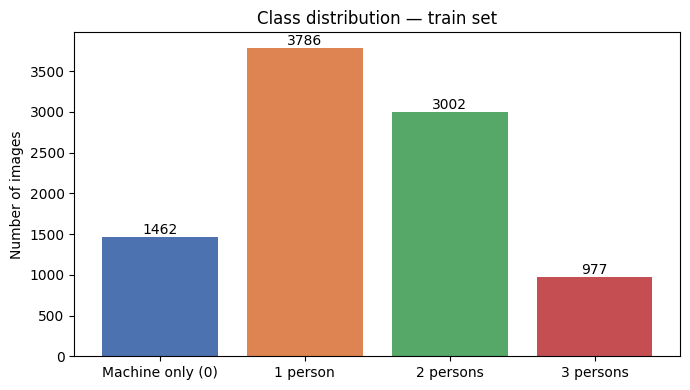

F1 saved.


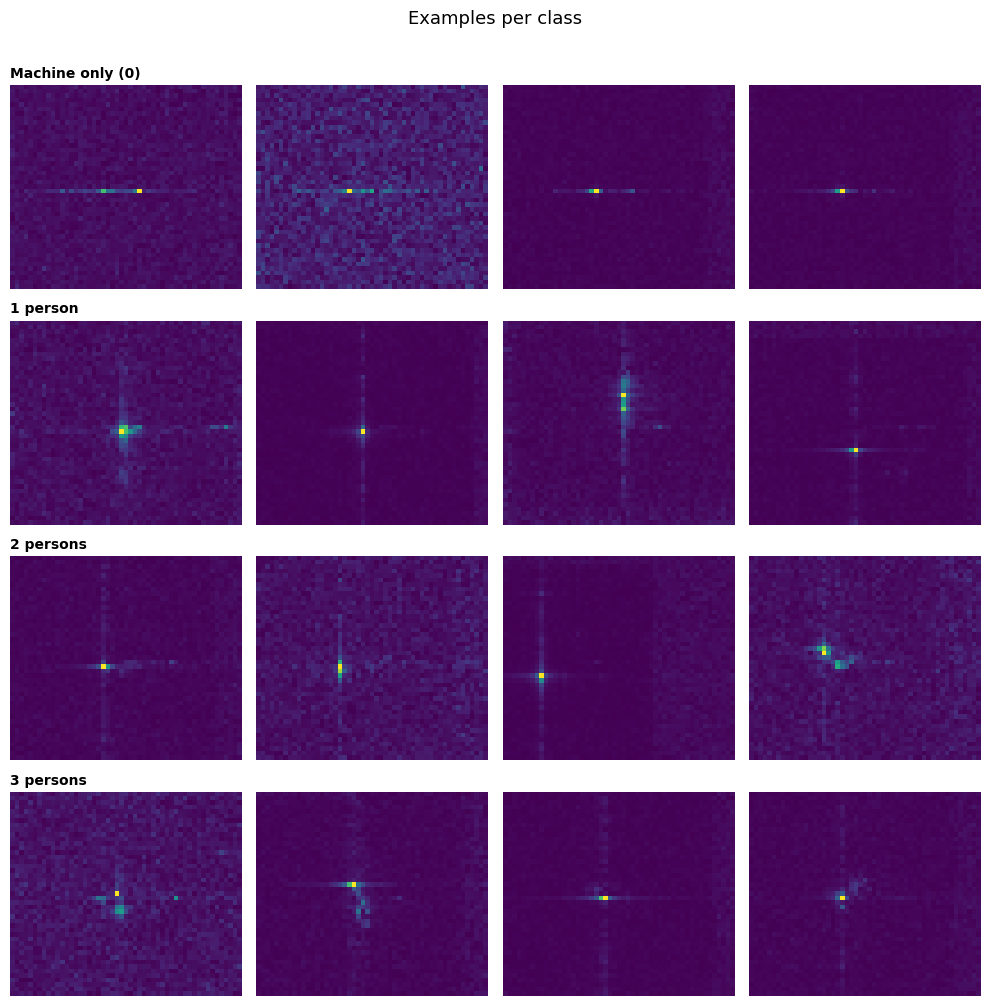

F2 saved.


In [110]:
# ============================================================
# F1 — Class distribution  |  F2 — Examples per class
# Pre-requisite: df, X_train, y_train, class_names in memory
# ============================================================
import os, numpy as np, matplotlib.pyplot as plt
os.makedirs('figures', exist_ok=True)

# F1 ---------------------------------------------------------
counts = df['target'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([class_names[i] for i in counts.index], counts.values,
              color=['#4C72B0','#DD8452','#55A868','#C44E52'])
ax.bar_label(bars, fmt='%d')
ax.set_title('Class distribution — train set')
ax.set_ylabel('Number of images')
plt.tight_layout()
plt.savefig('figures/F1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('F1 saved.')

# F2 ---------------------------------------------------------
N = 4
fig, axes = plt.subplots(4, N, figsize=(N * 2.5, 10))
for cls in range(4):
    idx = np.where(y_train == cls)[0][:N]
    for col, i in enumerate(idx):
        axes[cls, col].imshow(X_train[i])
        axes[cls, col].axis('off')
        if col == 0:
            axes[cls, col].set_title(class_names[cls], loc='left', fontsize=10, fontweight='bold')
plt.suptitle('Examples per class', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('figures/F2_examples_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('F2 saved.')

Epoch 1/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.6063 - loss: 0.9194 - val_accuracy: 0.7264 - val_loss: 0.5852
Epoch 2/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7977 - loss: 0.4805 - val_accuracy: 0.8325 - val_loss: 0.3898
Epoch 3/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8471 - loss: 0.3715 - val_accuracy: 0.8535 - val_loss: 0.3644
Epoch 4/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8798 - loss: 0.3042 - val_accuracy: 0.9128 - val_loss: 0.2344
Epoch 5/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8909 - loss: 0.2863 - val_accuracy: 0.9114 - val_loss: 0.2223
Epoch 6/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9068 - loss: 0.2430 - val_accuracy: 0.8688 - val_loss: 0.3230
Epoch 7/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9237 - loss: 0.2087 - val_accuracy: 0.9197 - val_loss: 0.2074
Epoch 8/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9274 - loss: 0.2041 - val_accuracy: 0.8925 - v

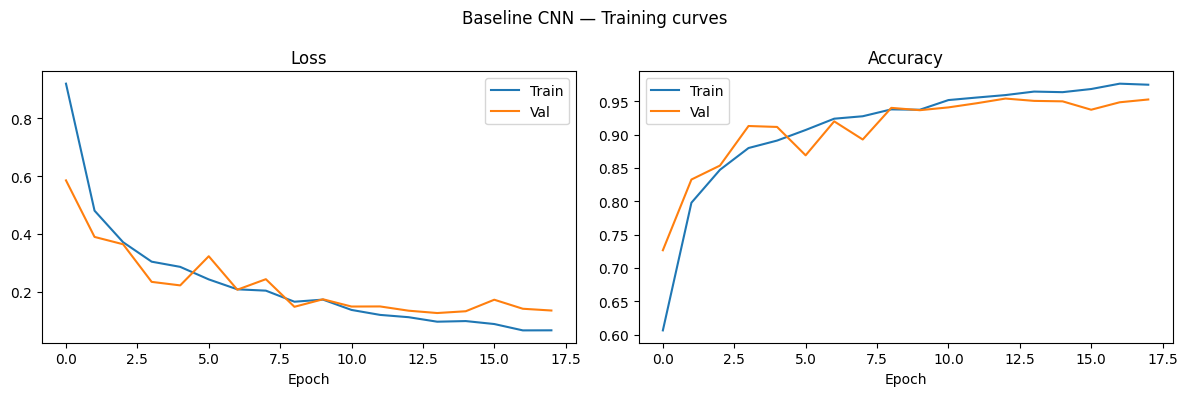

F3 saved. Best val acc: 0.9539


In [111]:
# F3 — Baseline CNN training curves (~30s on GPU)
import keras
from tensorflow.keras import layers

m_bl = keras.Sequential(name='cnn_baseline_fig')
m_bl.add(keras.Input(shape=(45, 51, 3)))
for f in [32, 64, 128]:
    m_bl.add(layers.Conv2D(f, (3, 3), padding='same', activation='relu'))
    m_bl.add(layers.MaxPooling2D((2, 2)))
m_bl.add(layers.Flatten())
m_bl.add(layers.Dense(128, activation='relu'))
m_bl.add(layers.Dense(4, activation='softmax'))
m_bl.compile(optimizer=keras.optimizers.Adam(1e-3),
             loss='sparse_categorical_crossentropy', metrics=['accuracy'])

h_bl = m_bl.fit(X_train, y_train, epochs=50, batch_size=64,
                validation_data=(X_val, y_val),
                callbacks=[keras.callbacks.EarlyStopping(
                    monitor='val_accuracy', patience=5, restore_best_weights=True)])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(h_bl.history['loss'], label='Train')
axes[0].plot(h_bl.history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[1].plot(h_bl.history['accuracy'], label='Train')
axes[1].plot(h_bl.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.suptitle('Baseline CNN — Training curves')
plt.tight_layout()
plt.savefig('figures/F3_baseline_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'F3 saved. Best val acc: {max(h_bl.history["val_accuracy"]):.4f}')

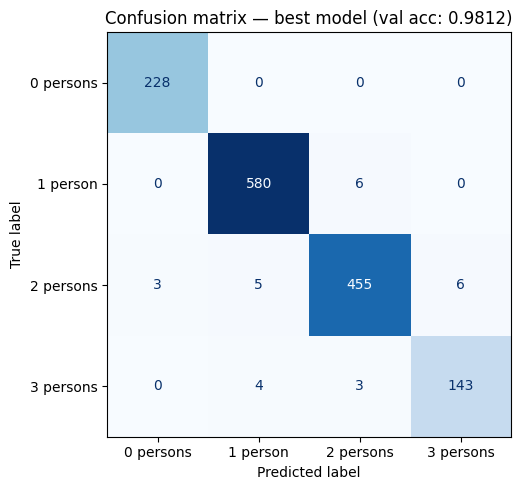

F5 saved. Val accuracy: 0.9812


In [112]:
# ============================================================
# F5 — Confusion matrix (best model: m_ls_0p05.keras)
# Fast: loads saved model, no training
# ============================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

m_ls_fig = keras.models.load_model(
    os.path.join(MODELS_DIR, 'm_ls_0p05.keras'),
    custom_objects={'loss': keras.losses.CategoricalCrossentropy(label_smoothing=0.05)}
)
y_pred_ls = np.argmax(m_ls_fig.predict(X_val, verbose=0), axis=1)
val_acc_ls = (y_pred_ls == y_val).mean()
cm = confusion_matrix(y_val, y_pred_ls)

class_labels = ['0 persons', '1 person', '2 persons', '3 persons']
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion matrix — best model (val acc: {val_acc_ls:.4f})')
plt.tight_layout()
plt.savefig('figures/F5_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'F5 saved. Val accuracy: {val_acc_ls:.4f}')

Epoch 1/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.6419 - loss: 0.8962 - val_accuracy: 0.8130 - val_loss: 0.5879
Epoch 2/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.8602 - loss: 0.5172 - val_accuracy: 0.8548 - val_loss: 0.5093
Epoch 3/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9079 - loss: 0.4134 - val_accuracy: 0.9288 - val_loss: 0.3882
Epoch 4/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9272 - loss: 0.3722 - val_accuracy: 0.9316 - val_loss: 0.3803
Epoch 5/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9494 - loss: 0.3306 - val_accuracy: 0.9379 - val_loss: 0.3515
Epoch 6/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9576 - loss: 0.3105 - val_accuracy: 0.9553 - val_loss: 0.3149
Epoch 7/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9670 - loss: 0.2925 - val_accuracy: 0.9505 - val_loss: 0.3316
Epoch 8/300
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9740 - loss: 0.2739 - val_accuracy: 0.

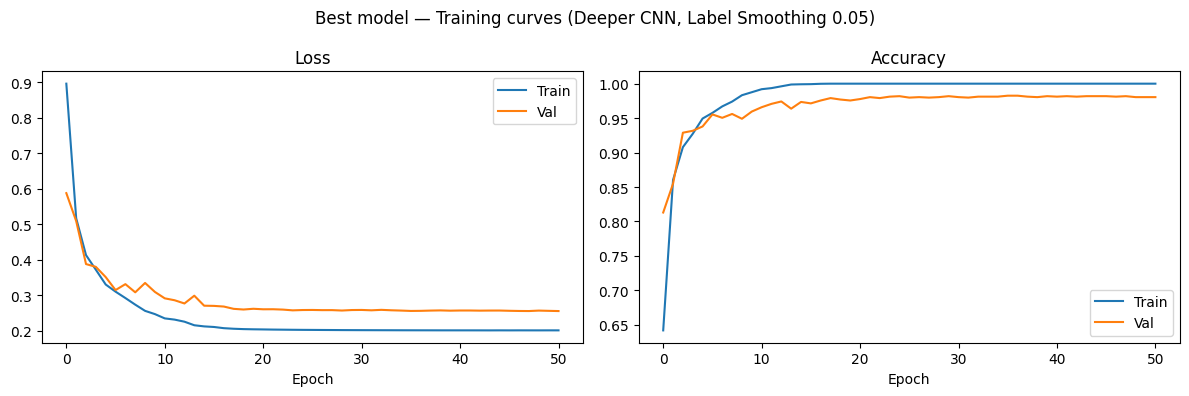

F4 saved. Best val acc: 0.9826


In [ ]:
# ============================================================
# F4 — Best model training curves (re-train for history)
# ============================================================
m_rep = build_cnn_v2(filters=(32, 64, 128, 256), dense_units=128,
                     dropout_rate=0.0, use_batchnorm=False)
m_rep.compile(optimizer=keras.optimizers.Nadam(learning_rate=0.002),
              loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
              metrics=['accuracy'])

h_rep = m_rep.fit(
    X_train, y_train_oh, epochs=300, batch_size=64,
    validation_data=(X_val, y_val_oh),
    callbacks=[keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=15,
        restore_best_weights=True, verbose=1)]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(h_rep.history['loss'], label='Train')
axes[0].plot(h_rep.history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[1].plot(h_rep.history['accuracy'], label='Train')
axes[1].plot(h_rep.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.suptitle('Best model — Training curves (Deeper CNN, Label Smoothing 0.05)')
plt.tight_layout()
plt.savefig('figures/F4_best_model_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'F4 saved. Best val acc: {max(h_rep.history["val_accuracy"]):.4f}')